# Introducción
A continuación, os presentamos la práctica final para el bloque de Python, cuyo objetivo principal es llevar a cabo un Análisis Exploratorio de Datos (EDA) a partir de un conjunto de datos abiertos de accidentes de tráfico en la ciudad de Madrid. Posteriormente, y usando la información obtenida, se entrenará un modelo de Regresión Logística que ayude a predecir la probabilidad de dar positivo en alcohol.


Los datos empleados en este EDA se encuentran publicados por el Ayuntamiento de Madrid y se pueden descargar en diferentes formatos (CSV o Excel). Adicionalmente, se cuenta con un documento PDF que describe la estructura de las variables. Este dataset contiene información detallada sobre los accidentes de tráfico: fecha, hora, tipo de accidente, tipo de persona implicada, etc..

Leer con atención todo el enunciado antes de entrar en detalle:

Dataset (elije solo un formato de datos):

Link Excel: https://datos.madrid.es/egob/catalogo/300228-29-accidentes-trafico-detalle.xlsx

Link csv: https://datos.madrid.es/egob/catalogo/300228-28-accidentes-trafico-detalle.csv

Descripción de los datos:
https://datos.madrid.es/FWProjects/egob/Catalogo/Seguridad/Ficheros/Estructura_ConjuntoDatos_Accidentesv2.pdf

#  Análisis Exploratorio de los Datos (EDA)

<b>Objetivo</b>

- Realizar un análisis exploratorio que ayude a entender la naturaleza de los datos y preparar la información para su posterior uso en un modelo de Machine Learning.
- Formular y responder a la siguiente pregunta de negocio relacionada con la información disponible: “¿En qué franja horaria se producen los accidentes con mayor gravedad (ingreso superior a 24 horas o fallecidos) y qué condiciones (estado meteorológico, tipo de accidente, etc.) pueden influir en ello?”

## Cargar los datos:

- Leer el fichero (CSV, Excel o el formato disponible).
- Inspeccionar la forma del dataframe (número de filas y columnas).
- Revisar los tipos de datos de cada columna (númerico, texto, fecha, etc.).

In [379]:
# importar las librerias necesarias para relaizar el EDA
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd
from pathlib import Path
plt.rcParams["figure.figsize"] = (8, 6)

In [381]:
# Leer el fichero (CSV) pathlib
file_path = Path("2024_Accidentalidad.csv")
db = pd.read_csv(file_path, sep=';')

Se utilizan rutas mediante pathlib para mejorar la portabilidad y reproducibilidad del código, evitando dependencias del sistema de archivos.
La separación en el archivo .csv lo hacen con ';' por tanto se tiene que especificar para no dar error.

In [5]:
# Ver los tipos de datos de cada columna (númerico, texto, fecha, etc.)
db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49340 entries, 0 to 49339
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   num_expediente        49340 non-null  object 
 1   fecha                 49340 non-null  object 
 2   hora                  49340 non-null  object 
 3   localizacion          49340 non-null  object 
 4   numero                49340 non-null  object 
 5   cod_distrito          49340 non-null  int64  
 6   distrito              49340 non-null  object 
 7   tipo_accidente        49335 non-null  object 
 8   estado_meteorológico  43424 non-null  object 
 9   tipo_vehiculo         48946 non-null  object 
 10  tipo_persona          49340 non-null  object 
 11  rango_edad            49340 non-null  object 
 12  sexo                  49340 non-null  object 
 13  cod_lesividad         27344 non-null  float64
 14  lesividad             27344 non-null  object 
 15  coordenada_x_utm   

In [6]:
# Inspeccionar la forma del dataframe (número de filas y columnas)
db.shape

(49340, 19)

**Análisis preliminar de la estructura del dataset:**
- El dataset contiene 49.340 filas y 19 columnas.
- Tipos de datos dectectados: `object` (texto/categóricas), `int64` (enteros) y `float64` (números decimales).
- Las columnas `fecha` y `hora` se han leído como texto (`object`) en lugar de como tipo temporal.

Para un análisis más correcto, es necesario realizar **conversiones de tipo de dato**.

Primeramente, visualizaremos el dataset para tener una idea de la estrucutra y los valores de cada columna.

In [8]:
# Mostrar primeras filas para inspección visual de los datos
db.head(3)

,num_expediente,fecha,hora,localizacion,numero,cod_distrito,distrito,tipo_accidente,estado_meteorológico,tipo_vehiculo,tipo_persona,rango_edad,sexo,cod_lesividad,lesividad,coordenada_x_utm,coordenada_y_utm,positiva_alcohol,positiva_droga
0,2023S040280,04/01/2024,14:09:00,AVDA. NICETO ALCALA ZAMORA / AUTOV. M-11,3,16,HORTALEZA,Colisión fronto-lateral,Lluvia débil,Motocicleta > 125cc,Conductor,De 55 a 59 años,Hombre,2.0,Ingreso inferior o igual a 24 horas,444913.0,4481427.0,N,NaN
1,2023S040280,04/01/2024,14:09:00,AVDA. NICETO ALCALA ZAMORA / AUTOV. M-11,3,16,HORTALEZA,Colisión fronto-lateral,Lluvia débil,Turismo,Conductor,De 55 a 59 años,Mujer,14.0,Sin asistencia sanitaria,444913.0,4481427.0,N,NaN
2,2023S040309,15/02/2024,14:05:00,CALL. TESORO / CALL. MINAS,18,1,CENTRO,Colisión fronto-lateral,Lluvia débil,Bicicleta,Conductor,De 25 a 29 años,Hombre,7.0,Asistencia sanitaria sólo en el lugar del acci...,440123.0,4475170.0,N,NaN


***Columna `fecha` y `hora`***

Vamos a combinar las columnas fecha y hora en una nueva columna llamada fecha_hora, convirtiéndola a tipo datetime. De esta forma podremos extraer información temporal (hora, día de la semana, mes, franjas horarias, etc.) y analizar los patrones de los accidentes de manera más sencilla.

In [10]:
# Crear columna datetime combinando fecha y hora
db['fecha_hora'] = pd.to_datetime(db['fecha'] + " " + db['hora'], format="%d/%m/%Y %H:%M:%S")

# Crear la columna de franja horaria a partir de la hora
def categorizar_hora(h):
    if 0 <= h < 6:
        return "Madrugada (0-6)"
    elif 6 <= h < 12:
        return "Mañana (6-12)"
    elif 12 <= h < 18:
        return "Tarde (12-18)"
    else:
        return "Noche (18-24)"

# Crear la columna 'franja_horaria' 
db['franja_horaria'] = db['fecha_hora'].dt.hour.apply(categorizar_hora)

# Crear columna 'hora_int' para poder estudiar horas puntas
db['hora_int'] = db['fecha_hora'].dt.hour

# Crear columna 'dia_sem' para poder saber el dia de la semana
db['dia_sem'] = db['fecha_hora'].dt.dayofweek

# Crear columna 'dia_sem' para poder saber el dia de la semana
db['mes'] = db['fecha_hora'].dt.month

In [11]:
db['fecha_hora'].dtype

dtype('<M8[ns]')

In [12]:
db.head()

,num_expediente,fecha,hora,localizacion,numero,cod_distrito,distrito,tipo_accidente,estado_meteorológico,tipo_vehiculo,...,lesividad,coordenada_x_utm,coordenada_y_utm,positiva_alcohol,positiva_droga,fecha_hora,franja_horaria,hora_int,dia_sem,mes
0,2023S040280,04/01/2024,14:09:00,AVDA. NICETO ALCALA ZAMORA / AUTOV. M-11,3,16,HORTALEZA,Colisión fronto-lateral,Lluvia débil,Motocicleta > 125cc,...,Ingreso inferior o igual a 24 horas,444913.0,4481427.0,N,NaN,2024-01-04 14:09:00,Tarde (12-18),14,3,1
1,2023S040280,04/01/2024,14:09:00,AVDA. NICETO ALCALA ZAMORA / AUTOV. M-11,3,16,HORTALEZA,Colisión fronto-lateral,Lluvia débil,Turismo,...,Sin asistencia sanitaria,444913.0,4481427.0,N,NaN,2024-01-04 14:09:00,Tarde (12-18),14,3,1
2,2023S040309,15/02/2024,14:05:00,CALL. TESORO / CALL. MINAS,18,1,CENTRO,Colisión fronto-lateral,Lluvia débil,Bicicleta,...,Asistencia sanitaria sólo en el lugar del acci...,440123.0,4475170.0,N,NaN,2024-02-15 14:05:00,Tarde (12-18),14,3,2
3,2023S040309,15/02/2024,14:05:00,CALL. TESORO / CALL. MINAS,18,1,CENTRO,Colisión fronto-lateral,Lluvia débil,Motocicleta hasta 125cc,...,Sin asistencia sanitaria,440123.0,4475170.0,N,NaN,2024-02-15 14:05:00,Tarde (12-18),14,3,2
4,2023S040310,18/02/2024,10:40:00,GTA. RUIZ JIMENEZ / CALL. SAN BERNARDO,3,7,CHAMBERÍ,Colisión lateral,Despejado,Turismo,...,NaN,440137.0,4475721.0,N,NaN,2024-02-18 10:40:00,Mañana (6-12),10,6,2



***Columna `num_expediente`***

In [14]:
db['num_expediente'].unique()

array(['2023S040280', '2023S040309', '2023S040310', ..., '2024S035474',
       '2024S035479', '2024S035480'], dtype=object)

El `num_expediente` contiene letras, por tanto se deja el tipo de dato como `object`

***Columna `numero`***

In [16]:
# Comprobar si todos los valores de 'numero' son numeros o contienen letras
db['numero'].unique()

array(['3', '18', '93', ..., '87A', '10XL01', '08RL40'], dtype=object)

Apreciamos que la columna `numero` no esta formada solo por numeros, por tanto se deja con el tipo `object`.

***Columna `cod_lesividad`***

In [18]:
# Comprobar si todos los numeros de 'cod_lesividad' son numeros
db['cod_lesividad'].unique()

array([ 2., 14.,  7., nan,  1.,  3.,  6.,  5.,  4., 77.])

El tipo de dato de `cod_lesividad` es un `float`, es un número, pero nos interesa convertirlo a `int` por temas prácticos. Ocupan menos espacio, dan más claridad semantica, es más facil para hacer agrupamientos y análisis catagoricos.

Para hacer la conversion de dato numerico sin alterar ni perder los `NaN`, se realizarà `.astype()` y no con `pd.to_numeric()`.

In [20]:
# Convertir los datos 'cod_lesividad' a tipo 'Int64'
db['cod_lesividad'] = db['cod_lesividad'].astype("Int64")


***Columna `positivo_alcohol`***

In [22]:
db['positiva_alcohol'].unique()

array(['N', 'S', nan], dtype=object)

Vamos a transformar la columna de tipo object a tipo int64 para facilitar los análisis categóricos, es decir **conversión de datos binarios a enteros**:

- Los valores 'S' se convertirán en 1.
- Los valores 'N' se convertirán en 0.

Esto permitirá realizar conteos, agrupaciones y análisis estadísticos sin problemas de tipo de dato.

In [24]:
# Convertir la categoria 'N' de la columna 'positiva_alcohol' a '0'
db.loc[db['positiva_alcohol'] == 'N', 'positiva_alcohol'] = '0'

# Convertir la categoria 'S' de la columna 'positiva_alcohol' a '1'
db.loc[db['positiva_alcohol'] == 'S', 'positiva_alcohol'] = '1'

In [25]:
db['positiva_alcohol'].unique()

array(['0', '1', nan], dtype=object)

In [26]:
# Convertir el tipo de dato 'object' a 'int64'
db['positiva_alcohol'] = db['positiva_alcohol'].astype('Int64')

In [27]:
db['positiva_alcohol'].unique()

<IntegerArray>
[0, 1, <NA>]
Length: 3, dtype: Int64

***Columna `positivo_droga`***

In [29]:
db['positiva_droga'].unique()

array([nan,  1.])

In [30]:
# Convertir el tipo de dato 'float64' a 'int64'
db['positiva_droga'] = db['positiva_droga'].astype('Int64')

In [31]:
db['positiva_droga'].unique()

<IntegerArray>
[<NA>, 1]
Length: 2, dtype: Int64

***Columnas categoricas***

Tenemos algunas columnas categoricas con el tipo de dato `object`:
- tipo_accidente
- tipo_vehiclulo
- tipo_pessona
- estado_meteorológico
- sexo
- rango_edad
- lesividad

Pasaremos estos datos a tipo `category`, ya que permite analisis agrupado y ocupa menos espacio.

In [33]:
# Columna 'sexo'
db['sexo'] = db['sexo'].astype('category')

# Columna 'tipo_accidente'
db['tipo_accidente'] = db['tipo_accidente'].astype('category')

# Columna 'tipo_vehiculo'
db['tipo_vehiculo'] = db['tipo_vehiculo'].astype('category')

# Columna 'tipo_persona'
db['tipo_persona'] = db['tipo_persona'].astype('category')

# Columna 'estado_meteorologico'
db['estado_meteorológico'] = db['estado_meteorológico'].astype('category')

# Columna 'rango_edad'
db['rango_edad'] = db['rango_edad'].astype('category')

# Columna 'lesividad'
db['lesividad'] = db['lesividad'].astype('category')

# Columna 'franja_horaria'
db['franja_horaria'] = db['franja_horaria'].astype('category')

In [34]:
db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49340 entries, 0 to 49339
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   num_expediente        49340 non-null  object        
 1   fecha                 49340 non-null  object        
 2   hora                  49340 non-null  object        
 3   localizacion          49340 non-null  object        
 4   numero                49340 non-null  object        
 5   cod_distrito          49340 non-null  int64         
 6   distrito              49340 non-null  object        
 7   tipo_accidente        49335 non-null  category      
 8   estado_meteorológico  43424 non-null  category      
 9   tipo_vehiculo         48946 non-null  category      
 10  tipo_persona          49340 non-null  category      
 11  rango_edad            49340 non-null  category      
 12  sexo                  49340 non-null  category      
 13  cod_lesividad   

## Limpieza de datos y tratamiento de valores nulos:

 - Identificar columnas con valores faltantes (“NULL”, “NaN”, etc.).
 - Decidir una estrategia para tratar valores nulos si es necesario (eliminar filas, rellenar con media o mediana, etc.). Reflexiona si tiene sentido o no.
 - Codificación de variables categóricas

In [36]:
# Identificar columnas con valores faltantes (“NULL”, “NaN”, etc.)
db.isnull().sum()

num_expediente              0
fecha                       0
hora                        0
localizacion                0
numero                      0
cod_distrito                0
distrito                    0
tipo_accidente              5
estado_meteorológico     5916
tipo_vehiculo             394
tipo_persona                0
rango_edad                  0
sexo                        0
cod_lesividad           21996
lesividad               21996
coordenada_x_utm            6
coordenada_y_utm            6
positiva_alcohol          167
positiva_droga          49137
fecha_hora                  0
franja_horaria              0
hora_int                    0
dia_sem                     0
mes                         0
dtype: int64

A simple vista podemos observar los valores nulos (`NaN`) presentes en el dataset.

**Nulos `tipo_accidente`**

En primer lugar, para los valores no nulos en `tipo_accidente` la estrategia más directa sería eliminarlos, ya que únicamente afectan a 5 filas dentro de un conjunto de 49340, por lo que su impacto global seria despreciable.

No obstante, al explorar la información de estas filas se observa que una de ellas presenta el valor `1.0` en la columna `positiva_droga`. Esta variable es especialmente escasa en el dataset, ya que solo cuenta con 203 registrados sobre el total. 
Por ello, conviene analizar cuidadosamente la estrategia a seguir, ya que la eliminación de estas filas podría implicar la pérdida de información relevante.

In [38]:
# Crear un db para las filas contienen null en 'tipo_accidente'
db_tipo_accidente_null = db[db['tipo_accidente'].isnull()]

In [39]:
db_tipo_accidente_null

,num_expediente,fecha,hora,localizacion,numero,cod_distrito,distrito,tipo_accidente,estado_meteorológico,tipo_vehiculo,...,lesividad,coordenada_x_utm,coordenada_y_utm,positiva_alcohol,positiva_droga,fecha_hora,franja_horaria,hora_int,dia_sem,mes
45370,2024S033213,05/12/2024,2:45:00,AVDA. JOAQUIN GARRIGUES WALKER / CALL. ESTEBAN...,15,13,PUENTE DE VALLECAS,NaN,NaN,Turismo,...,NaN,NaN,NaN,1,<NA>,2024-12-05 02:45:00,Madrugada (0-6),2,3,12
48148,2024S034789,22/12/2024,6:10:00,"CALL. GRAN VIA, 46",46,1,CENTRO,NaN,NaN,Motocicleta hasta 125cc,...,Ingreso superior a 24 horas,440105.0,4474654.0,1,1,2024-12-22 06:10:00,Mañana (6-12),6,6,12
48149,2024S034789,22/12/2024,6:10:00,"CALL. GRAN VIA, 46",46,1,CENTRO,NaN,NaN,Turismo,...,Sin asistencia sanitaria,440105.0,4474654.0,0,<NA>,2024-12-22 06:10:00,Mañana (6-12),6,6,12
48150,2024S034789,22/12/2024,6:10:00,"CALL. GRAN VIA, 46",46,1,CENTRO,NaN,NaN,Turismo,...,NaN,440105.0,4474654.0,0,<NA>,2024-12-22 06:10:00,Mañana (6-12),6,6,12
48151,2024S034789,22/12/2024,6:10:00,"CALL. GRAN VIA, 46",46,1,CENTRO,NaN,NaN,Turismo,...,NaN,440105.0,4474654.0,0,<NA>,2024-12-22 06:10:00,Mañana (6-12),6,6,12


**Decisión final:** eliminamos las 5 filas nulas en `tipo_accidente`.

Tras consultar la documentación oficial proporcionada en el anunciado, se comprueba que estos nuls en la variable `positivo_droga` no representan valores desconocidos, sino que equivalen a resultados negativos. Esto a simple vista puede confundir si no se revisa cuidadosamente la información del dataset, por lo que resulta imprescindible revisar bien los datos con la documentación previa. 

Al saber que no son nulos reales podemos proceder a la primera estrategia, la eliminación de las 5 filas. Estas filas representan aproximadamente un 0.01% del dataset. Estamos hablando de porcentajes mínimos y por tanto no relevantes para el estudio principal.


In [41]:
# Eliminamos las 5 filas
db = db[~db['tipo_accidente'].isnull()]

# Tambien se puede usar el db creado anteriormente, es lo mismo
# db = db[~db_tipo_accidente_null]

db.isnull().sum()

num_expediente              0
fecha                       0
hora                        0
localizacion                0
numero                      0
cod_distrito                0
distrito                    0
tipo_accidente              0
estado_meteorológico     5911
tipo_vehiculo             394
tipo_persona                0
rango_edad                  0
sexo                        0
cod_lesividad           21993
lesividad               21993
coordenada_x_utm            5
coordenada_y_utm            5
positiva_alcohol          167
positiva_droga          49133
fecha_hora                  0
franja_horaria              0
hora_int                    0
dia_sem                     0
mes                         0
dtype: int64

In [42]:
db.shape

(49335, 24)

**Nulos `positiva_droga`**

Durante el análisis de los valores nulos de `tipo_accidente`, consideramos también la estrategia para los nulos de `positivo_droga`. En este caso, según la documentación oficial del dataset, sabemos que los valores nulos equivalen a resultados negativos en la prueba de drogas.

Por ello, reemplazamos los nulos por `0` (negativo), mientras que los positivos se representan con `1`.
De este modo, la variable queda representada como un dato binario (0/1), lo que facilita tanto el análisis exploratorio (cálculo de proporciones, comparaciones, etc.) como la preparación del dataset para modelos de Machine Learning.

In [44]:
# Sustituimos NaN en 'positiva_droga' con 0, manteniendo 1 como positivo
db['positiva_droga'] = db['positiva_droga'].fillna(0).astype(int)

# Comprobamos que se han sustituido todos los NaN correctamente
db.isnull().sum()

num_expediente              0
fecha                       0
hora                        0
localizacion                0
numero                      0
cod_distrito                0
distrito                    0
tipo_accidente              0
estado_meteorológico     5911
tipo_vehiculo             394
tipo_persona                0
rango_edad                  0
sexo                        0
cod_lesividad           21993
lesividad               21993
coordenada_x_utm            5
coordenada_y_utm            5
positiva_alcohol          167
positiva_droga              0
fecha_hora                  0
franja_horaria              0
hora_int                    0
dia_sem                     0
mes                         0
dtype: int64

In [45]:
# Comprobamos que se ha cambiado correctamente
db.head(2)

,num_expediente,fecha,hora,localizacion,numero,cod_distrito,distrito,tipo_accidente,estado_meteorológico,tipo_vehiculo,...,lesividad,coordenada_x_utm,coordenada_y_utm,positiva_alcohol,positiva_droga,fecha_hora,franja_horaria,hora_int,dia_sem,mes
0,2023S040280,04/01/2024,14:09:00,AVDA. NICETO ALCALA ZAMORA / AUTOV. M-11,3,16,HORTALEZA,Colisión fronto-lateral,Lluvia débil,Motocicleta > 125cc,...,Ingreso inferior o igual a 24 horas,444913.0,4481427.0,0,0,2024-01-04 14:09:00,Tarde (12-18),14,3,1
1,2023S040280,04/01/2024,14:09:00,AVDA. NICETO ALCALA ZAMORA / AUTOV. M-11,3,16,HORTALEZA,Colisión fronto-lateral,Lluvia débil,Turismo,...,Sin asistencia sanitaria,444913.0,4481427.0,0,0,2024-01-04 14:09:00,Tarde (12-18),14,3,1


Y como hemos dicho anteriormente, hemos dejado la conversion de tipo de dato para despues del tratamiento de nulos, es decir que ahora procedemos a realizar el tipo de dato `object` a `int64`.

**Nulos `estado_meteorológico`**

Para decidir la estrategia más acertada, primero identificamos las categorías existentes en la variable `estado_meteorológico` explorando los valores únicos presentes.

In [48]:
db['estado_meteorológico'].unique()

['Lluvia débil', 'Despejado', NaN, 'Nublado', 'Se desconoce', 'LLuvia intensa', 'Granizando', 'Nevando']
Categories (7, object): ['Despejado', 'Granizando', 'LLuvia intensa', 'Lluvia débil', 'Nevando', 'Nublado', 'Se desconoce']

**Decisión final:** Sustituir los nulos por una categoría existente.

Como podemos observar, ya existe un valor denominado `Se deconoce`. Por lo tanto, en este caso reemplazaremos los valores `NaN` por el valor `Se desconoce`.

In [50]:
db['estado_meteorológico'] = db['estado_meteorológico'].fillna('Se desconoce')

# Comprobamos que no hay ningíun NaN
db['estado_meteorológico'].unique()

['Lluvia débil', 'Despejado', 'Se desconoce', 'Nublado', 'LLuvia intensa', 'Granizando', 'Nevando']
Categories (7, object): ['Despejado', 'Granizando', 'LLuvia intensa', 'Lluvia débil', 'Nevando', 'Nublado', 'Se desconoce']

In [51]:
# Comprobamos que se han sustituido todos los NaN de la categoria correctamente
db.isnull().sum()

num_expediente              0
fecha                       0
hora                        0
localizacion                0
numero                      0
cod_distrito                0
distrito                    0
tipo_accidente              0
estado_meteorológico        0
tipo_vehiculo             394
tipo_persona                0
rango_edad                  0
sexo                        0
cod_lesividad           21993
lesividad               21993
coordenada_x_utm            5
coordenada_y_utm            5
positiva_alcohol          167
positiva_droga              0
fecha_hora                  0
franja_horaria              0
hora_int                    0
dia_sem                     0
mes                         0
dtype: int64

**Nulos `tipo_vehiculo`**

Aplicaremos el mismo método que en `estado_meteorologico`: exploraremos las categorias existentes para ver si hay alguna similar a `Se desconoce`

In [53]:
db['tipo_vehiculo'].value_counts()

tipo_vehiculo
Turismo                              33870
Motocicleta hasta 125cc               3308
Furgoneta                             3236
Motocicleta > 125cc                   1805
Autobús                               1501
Camión rígido                         1164
Todo terreno                           829
Bicicleta                              812
VMU eléctrico                          771
Ciclomotor                             471
Bicicleta EPAC (pedaleo asistido)      264
Tractocamión                           212
Maquinaria de obras                    182
Otros vehículos con motor              164
Vehículo articulado                     84
Autobús articulado                      78
Cuadriciclo ligero                      42
Sin especificar                         37
Autobus EMT                             27
Cuadriciclo no ligero                   19
Ciclo                                   17
Autocaravana                            14
Otros vehículos sin motor               

**Decisión final:** Sustituir los nulos por una categoría existente.

Existe una variable `Sin especificar` que resulta adecuada para reemplazar los valores `NaN` en esta columna.

In [55]:
db['tipo_vehiculo'] = db['tipo_vehiculo'].fillna('Sin especificar')

In [56]:
# Comprobamos que se han sustituido todos los NaN de la categoria correctamente
db.isnull().sum()

num_expediente              0
fecha                       0
hora                        0
localizacion                0
numero                      0
cod_distrito                0
distrito                    0
tipo_accidente              0
estado_meteorológico        0
tipo_vehiculo               0
tipo_persona                0
rango_edad                  0
sexo                        0
cod_lesividad           21993
lesividad               21993
coordenada_x_utm            5
coordenada_y_utm            5
positiva_alcohol          167
positiva_droga              0
fecha_hora                  0
franja_horaria              0
hora_int                    0
dia_sem                     0
mes                         0
dtype: int64

In [57]:
db['tipo_vehiculo'].value_counts()

tipo_vehiculo
Turismo                              33870
Motocicleta hasta 125cc               3308
Furgoneta                             3236
Motocicleta > 125cc                   1805
Autobús                               1501
Camión rígido                         1164
Todo terreno                           829
Bicicleta                              812
VMU eléctrico                          771
Ciclomotor                             471
Sin especificar                        431
Bicicleta EPAC (pedaleo asistido)      264
Tractocamión                           212
Maquinaria de obras                    182
Otros vehículos con motor              164
Vehículo articulado                     84
Autobús articulado                      78
Cuadriciclo ligero                      42
Autobus EMT                             27
Cuadriciclo no ligero                   19
Ciclo                                   17
Autocaravana                            14
Otros vehículos sin motor               

Podemos observar que ya no existen valores nulos en la columna `tipo_vehiculo` y que la categoría `Sin especificar` ha aumentado. Esto corresponde a la suma del valor original de la categoría con los valores que antes eran nulos.


**Nulos `lesividad` y `cod_lesividad`**

Para poder aplicar una estrategia, vamos a usar directamente la información que nos ofrece la documentación oficial:

LESIVIDAD:

- 01 Atención en urgencias sin posterior ingreso. - LEVE
- 02 Ingreso inferior o igual a 24 horas - LEVE
- 03 Ingreso superior a 24 horas. - GRAVE
- 04 Fallecido 24 horas - FALLECIDO
- 05 Asistencia sanitaria ambulatoria con posterioridad - LEVE
- 06 Asistencia sanitaria inmediata en centro de salud o mutua - LEVE
- 07 Asistencia sanitaria sólo en el lugar del accidente - LEVE
- 14 Sin asistencia sanitaria
- 77 Se desconoce


In [60]:
# Comprobamos las categorias de lesividad
db['lesividad'].unique()

['Ingreso inferior o igual a 24 horas', 'Sin asistencia sanitaria', 'Asistencia sanitaria sólo en el lugar del acc..., NaN, 'Atención en urgencias sin posterior ingreso', 'Ingreso superior a 24 horas', 'Asistencia sanitaria inmediata en centro de s..., 'Asistencia sanitaria ambulatoria con posterio..., 'Fallecido 24 horas', 'Se desconoce']
Categories (9, object): ['Asistencia sanitaria ambulatoria con posterio..., 'Asistencia sanitaria inmediata en centro de s..., 'Asistencia sanitaria sólo en el lugar del acc..., 'Atención en urgencias sin posterior ingreso', ..., 'Ingreso inferior o igual a 24 horas', 'Ingreso superior a 24 horas', 'Se desconoce', 'Sin asistencia sanitaria']

In [61]:
# Comprobamos las categorias de cod_lesividad
db['cod_lesividad'].unique()

<IntegerArray>
[2, 14, 7, <NA>, 1, 3, 6, 5, 4, 77]
Length: 10, dtype: Int64

Una vez comprobado que la información oficial se correlaciona con la del dataset tomamos una decisión.

**Decisión final:** Sustituir los nulos por una categoría o valor existente.
- En la columna `lesividad` aplicaremos el mismo método que en el caso anterior, sustituir los `NaN` por la categoria `Se desconoce`.
- Y en el caso de `cod_lesividad` sustituir los nulos por el numero `77`.

In [63]:
db['lesividad'] = db['lesividad'].fillna('Se desconoce')
db['lesividad'].value_counts()

lesividad
Se desconoce                                                 21995
Sin asistencia sanitaria                                     16115
Asistencia sanitaria sólo en el lugar del accidente           5789
Ingreso inferior o igual a 24 horas                           1865
Atención en urgencias sin posterior ingreso                   1337
Asistencia sanitaria inmediata en centro de salud o mutua     1116
Ingreso superior a 24 horas                                    567
Asistencia sanitaria ambulatoria con posterioridad             522
Fallecido 24 horas                                              29
Name: count, dtype: int64

In [64]:
db['cod_lesividad'] = db['cod_lesividad'].fillna(77)
db['cod_lesividad'].value_counts()

cod_lesividad
77    21995
14    16115
7      5789
2      1865
1      1337
6      1116
3       567
5       522
4        29
Name: count, dtype: Int64

El valor total de la categoria `lesividad` coincide con el total de `cod_lesividad`, esto nos confirma que la sustitución de nulos se ha realizado de forma correcta.

In [66]:
db.isnull().sum()

num_expediente            0
fecha                     0
hora                      0
localizacion              0
numero                    0
cod_distrito              0
distrito                  0
tipo_accidente            0
estado_meteorológico      0
tipo_vehiculo             0
tipo_persona              0
rango_edad                0
sexo                      0
cod_lesividad             0
lesividad                 0
coordenada_x_utm          5
coordenada_y_utm          5
positiva_alcohol        167
positiva_droga            0
fecha_hora                0
franja_horaria            0
hora_int                  0
dia_sem                   0
mes                       0
dtype: int64

In [67]:
db.shape

(49335, 24)

**Nulos `positivo_alcohol`**

Los nulos que hay en la columna `positivo_alcohol` representan solo un 0,34% del total de datos. Aunque podríamos eliminarlos directamente, primero revisaremos estas filas para comprobar si alguna es crítica para nuestro estudio, verificando posibles relaciones con valores relevantes en otras columnas.

In [69]:
# Comprobar si algun NaN de 'positiva_alcohol' tiene positivo en droga
db[db['positiva_alcohol'].isnull() & (db['positiva_droga'] == 1)].shape

(0, 24)

In [70]:
# Comprobar si algun NaN de 'positiva_alcohol' tiene 'cod_lesividad' diferente de 77
db[db['positiva_alcohol'].isnull() & (db['cod_lesividad'] != 77)].shape

(0, 24)

In [71]:
# Ver cuales son los valores más críticos en 'estado_meteorológico'
db['estado_meteorológico'].value_counts()

estado_meteorológico
Despejado         36735
Se desconoce       6267
Nublado            3464
Lluvia débil       2395
LLuvia intensa      464
Granizando            8
Nevando               2
Name: count, dtype: int64

In [72]:
# Comprobar si algun NaN de 'positiva_alcohol' tiene 'estado_meteorologico' 'Nevando' o 'Granizando'
db[db['positiva_alcohol'].isnull() & ((db['estado_meteorológico'] == 'Granizando') | (db['estado_meteorológico'] == 'Nevando'))].shape

(0, 24)

In [73]:
# Ver cuales son los valores más críticos en 'tipo_vehiculo'
db['tipo_vehiculo'].value_counts()

tipo_vehiculo
Turismo                              33870
Motocicleta hasta 125cc               3308
Furgoneta                             3236
Motocicleta > 125cc                   1805
Autobús                               1501
Camión rígido                         1164
Todo terreno                           829
Bicicleta                              812
VMU eléctrico                          771
Ciclomotor                             471
Sin especificar                        431
Bicicleta EPAC (pedaleo asistido)      264
Tractocamión                           212
Maquinaria de obras                    182
Otros vehículos con motor              164
Vehículo articulado                     84
Autobús articulado                      78
Cuadriciclo ligero                      42
Autobus EMT                             27
Cuadriciclo no ligero                   19
Ciclo                                   17
Autocaravana                            14
Otros vehículos sin motor               

In [74]:
# Ver que categorias en 'tipo_vehiculo' tienen las filas con nulos en 'positiva_alcohol'
db[db['positiva_alcohol'].isnull()]['tipo_vehiculo'].unique()

['Turismo', 'Autobús', 'Sin especificar', 'Camión rígido', 'Furgoneta', 'Todo terreno', 'Motocicleta > 125cc', 'Motocicleta hasta 125cc', 'Maquinaria de obras', 'Tractocamión']
Categories (32, object): ['Ambulancia SAMUR', 'Autobus EMT', 'Autobús', 'Autobús articulado', ..., 'Tractocamión', 'Turismo', 'VMU eléctrico', 'Vehículo articulado']

Con estas comprobaciones hemos visto que todas las filas que conienen nulos en la columna `positva_alcohol` tienen:
- La columna de `lesividad` con la categoria `Se desconoce`.
- Todos son negativos en drogas.
- No tienen la categoria `Granizando` ni `Nevando` en la columna `estado_meteorológico` (categorías importantes, ya que solo tenemos 8 y 2 filas respectivamente).
- Todas las categorias que hay en la columna `tipo_vehiculo` no son críticas.


**Decisión final:** Eliminar las filas con valores nulos en `positiva_alcohol`.

Tras analizar los datos, confirmamos que las filas con valores nulos en esta columna no contienen información crítica para nuestro estudio. Por tanto, su eliminación no afectará el análisis ni los resultados finales.

In [77]:
# Eliminamos las filas con nulos en la columna 'positivo_alcohol'
db = db[~db['positiva_alcohol'].isnull()]
db.isnull().sum()

num_expediente          0
fecha                   0
hora                    0
localizacion            0
numero                  0
cod_distrito            0
distrito                0
tipo_accidente          0
estado_meteorológico    0
tipo_vehiculo           0
tipo_persona            0
rango_edad              0
sexo                    0
cod_lesividad           0
lesividad               0
coordenada_x_utm        5
coordenada_y_utm        5
positiva_alcohol        0
positiva_droga          0
fecha_hora              0
franja_horaria          0
hora_int                0
dia_sem                 0
mes                     0
dtype: int64

**Nulos `coordenada_x_utm` y `coordenada_y_utm`**

En estas dos variables únicamente se identifican 5 filas con valores nulos en cada una, lo que representa aproximadamente un 0,01% del total del dataset. A primera vista, la estrategia más sencilla sería eliminarlos directamente.

No obstante, antes vamos a analizar la información disponible y comprobar si los valores nulos en `coordenada_x_utm` coinciden con las de `coordenada_y_utm`, es decir, si los nulos aparecen de forma alineada en ambas columnas.

In [79]:
# Mostrar las filas con nulos
db[db['coordenada_x_utm'].isnull()]

,num_expediente,fecha,hora,localizacion,numero,cod_distrito,distrito,tipo_accidente,estado_meteorológico,tipo_vehiculo,...,lesividad,coordenada_x_utm,coordenada_y_utm,positiva_alcohol,positiva_droga,fecha_hora,franja_horaria,hora_int,dia_sem,mes
43126,2024S031973,21/11/2024,7:55:00,"AUTOV. M-30, 22NC40",22NC40,9,MONCLOA-ARAVACA,Alcance,Despejado,Turismo,...,Se desconoce,NaN,NaN,0,0,2024-11-21 07:55:00,Mañana (6-12),7,3,11
45331,2024S033186,04/12/2024,20:45:00,"CALL. SAGASTA, 12",12,1,CENTRO,Caída,Se desconoce,Bicicleta,...,Se desconoce,NaN,NaN,0,0,2024-12-04 20:45:00,Noche (18-24),20,2,12
45332,2024S033186,04/12/2024,20:45:00,"CALL. SAGASTA, 12",12,1,CENTRO,Caída,Se desconoce,Turismo,...,Se desconoce,NaN,NaN,0,0,2024-12-04 20:45:00,Noche (18-24),20,2,12
46526,2024S033868,12/12/2024,9:40:00,"AUTOV. M-30, 04XL65",04XL65,15,CIUDAD LINEAL,Caída,Despejado,Sin especificar,...,Asistencia sanitaria sólo en el lugar del acci...,NaN,NaN,0,0,2024-12-12 09:40:00,Mañana (6-12),9,3,12
47617,2024S034459,19/12/2024,10:25:00,"CALL. LOS YEBENES, 78",78,10,LATINA,Caída,Lluvia débil,Motocicleta hasta 125cc,...,Asistencia sanitaria sólo en el lugar del acci...,NaN,NaN,0,0,2024-12-19 10:25:00,Mañana (6-12),10,3,12


Al analizar los datos, observamos que las filas con valores nulos en `coordenada_x_utm`  coinciden exactamente con aquellas que presentan nulos en `coordenada_y_utm`.

Además, todas estas filas contienen información en la columna localización, lo que nos permite plantear una estrategia de relleno basado en información relacionada, es decir, sustituir los valores nulos por las coordenadas ya existentes en filas con la misma categoría de localización.

Antes de aplicar esta estrategia, verificaremos que sea consistente, comprobando si para cada localización las coordenadas disponibles son únicas o si existen múltiples opciones posibles.

In [81]:
db[db['localizacion'] == 'CALL. SAGASTA, 12']

,num_expediente,fecha,hora,localizacion,numero,cod_distrito,distrito,tipo_accidente,estado_meteorológico,tipo_vehiculo,...,lesividad,coordenada_x_utm,coordenada_y_utm,positiva_alcohol,positiva_droga,fecha_hora,franja_horaria,hora_int,dia_sem,mes
45331,2024S033186,04/12/2024,20:45:00,"CALL. SAGASTA, 12",12,1,CENTRO,Caída,Se desconoce,Bicicleta,...,Se desconoce,NaN,NaN,0,0,2024-12-04 20:45:00,Noche (18-24),20,2,12
45332,2024S033186,04/12/2024,20:45:00,"CALL. SAGASTA, 12",12,1,CENTRO,Caída,Se desconoce,Turismo,...,Se desconoce,NaN,NaN,0,0,2024-12-04 20:45:00,Noche (18-24),20,2,12
47840,2024S034586,20/12/2024,13:00:00,"CALL. SAGASTA, 12",12,1,CENTRO,Caída,Despejado,Motocicleta hasta 125cc,...,Asistencia sanitaria sólo en el lugar del acci...,440623.0,4475550.0,0,0,2024-12-20 13:00:00,Tarde (12-18),13,4,12
47841,2024S034586,20/12/2024,13:00:00,"CALL. SAGASTA, 12",12,1,CENTRO,Caída,Despejado,Motocicleta hasta 125cc,...,Sin asistencia sanitaria,440623.0,4475550.0,0,0,2024-12-20 13:00:00,Tarde (12-18),13,4,12


Observamos las filas con la misma localización (CALL. SAGASTA, 12) comparten el mismo valor en `coordenada_x_utm` y `coordenada_y_utm`. 

Como en todas las demás entradas de esa localización las coordenadas son constantes, decidimos imputar los valores faltantes con dichas coordenadas en lugar de eliminar las filas, evitando así pérdida de información.

In [83]:
# Guardar el valor de coordenada 'X' en una variable
coord_x = db.loc[db['localizacion']  == 'CALL. SAGASTA, 12', 'coordenada_x_utm'].dropna().unique()
coord_x

array([440623.])

In [84]:
# Guardar el valor de coordenada 'Y' en una variable
coord_y = db.loc[db['localizacion'] == 'CALL. SAGASTA, 12', 'coordenada_y_utm'].dropna().unique()
coord_y

array([4475550.])

In [85]:
# Sustituir el valor de coordenada en las filas donde coincidan que la coordenada sea nula y la localización 'CALL. SAGASTA, 12' 

# Coordenada 'X'
db.loc[
    (db['localizacion'] == 'CALL. SAGASTA, 12') & (db['coordenada_x_utm'].isnull()), 'coordenada_x_utm'
] = coord_x[0]

# Coordenada 'Y'
db.loc[
    (db['localizacion'] == 'CALL. SAGASTA, 12') & (db['coordenada_y_utm'].isnull()), 'coordenada_y_utm'
] = coord_y[0]

In [86]:
# Comprobar que se han sustituido correctamente
db[db['localizacion'] == 'CALL. SAGASTA, 12']

,num_expediente,fecha,hora,localizacion,numero,cod_distrito,distrito,tipo_accidente,estado_meteorológico,tipo_vehiculo,...,lesividad,coordenada_x_utm,coordenada_y_utm,positiva_alcohol,positiva_droga,fecha_hora,franja_horaria,hora_int,dia_sem,mes
45331,2024S033186,04/12/2024,20:45:00,"CALL. SAGASTA, 12",12,1,CENTRO,Caída,Se desconoce,Bicicleta,...,Se desconoce,440623.0,4475550.0,0,0,2024-12-04 20:45:00,Noche (18-24),20,2,12
45332,2024S033186,04/12/2024,20:45:00,"CALL. SAGASTA, 12",12,1,CENTRO,Caída,Se desconoce,Turismo,...,Se desconoce,440623.0,4475550.0,0,0,2024-12-04 20:45:00,Noche (18-24),20,2,12
47840,2024S034586,20/12/2024,13:00:00,"CALL. SAGASTA, 12",12,1,CENTRO,Caída,Despejado,Motocicleta hasta 125cc,...,Asistencia sanitaria sólo en el lugar del acci...,440623.0,4475550.0,0,0,2024-12-20 13:00:00,Tarde (12-18),13,4,12
47841,2024S034586,20/12/2024,13:00:00,"CALL. SAGASTA, 12",12,1,CENTRO,Caída,Despejado,Motocicleta hasta 125cc,...,Sin asistencia sanitaria,440623.0,4475550.0,0,0,2024-12-20 13:00:00,Tarde (12-18),13,4,12


In [87]:
# Verificar cuantos nulos quedan
db.isnull().sum()

num_expediente          0
fecha                   0
hora                    0
localizacion            0
numero                  0
cod_distrito            0
distrito                0
tipo_accidente          0
estado_meteorológico    0
tipo_vehiculo           0
tipo_persona            0
rango_edad              0
sexo                    0
cod_lesividad           0
lesividad               0
coordenada_x_utm        3
coordenada_y_utm        3
positiva_alcohol        0
positiva_droga          0
fecha_hora              0
franja_horaria          0
hora_int                0
dia_sem                 0
mes                     0
dtype: int64

In [88]:
# Mostrar cuales son las localizaciones restantes donde las coordenadas son NaN
db.loc[db['coordenada_x_utm'].isnull(), 'localizacion'].value_counts()

localizacion
AUTOV. M-30, 22NC40      1
AUTOV. M-30, 04XL65      1
CALL. LOS YEBENES, 78    1
Name: count, dtype: int64

In [89]:
# Visualizar las filas con localización 'AUTOV. M-30, 04XL65'
db[db['localizacion'] == 'AUTOV. M-30, 04XL65']

,num_expediente,fecha,hora,localizacion,numero,cod_distrito,distrito,tipo_accidente,estado_meteorológico,tipo_vehiculo,...,lesividad,coordenada_x_utm,coordenada_y_utm,positiva_alcohol,positiva_droga,fecha_hora,franja_horaria,hora_int,dia_sem,mes
45304,2024S033172,04/12/2024,15:45:00,"AUTOV. M-30, 04XL65",04XL65,15,CIUDAD LINEAL,Caída,Despejado,Motocicleta hasta 125cc,...,Asistencia sanitaria sólo en el lugar del acci...,443997.0,4477392.0,0,0,2024-12-04 15:45:00,Tarde (12-18),15,2,12
46526,2024S033868,12/12/2024,9:40:00,"AUTOV. M-30, 04XL65",04XL65,15,CIUDAD LINEAL,Caída,Despejado,Sin especificar,...,Asistencia sanitaria sólo en el lugar del acci...,NaN,NaN,0,0,2024-12-12 09:40:00,Mañana (6-12),9,3,12


In [90]:
# Obtener y guardar las coordenadas en valores
coord_x = db.loc[db['localizacion']  == 'AUTOV. M-30, 04XL65', 'coordenada_x_utm'].dropna().unique()
coord_y = db.loc[db['localizacion'] == 'AUTOV. M-30, 04XL65', 'coordenada_y_utm'].dropna().unique()

# Sustituir los valores en el dataset
db.loc[
    (db['localizacion'] == 'AUTOV. M-30, 04XL65') & (db['coordenada_x_utm'].isnull()), 'coordenada_x_utm'
] = coord_x[0]

db.loc[
    (db['localizacion'] == 'AUTOV. M-30, 04XL65') & (db['coordenada_y_utm'].isnull()), 'coordenada_y_utm'
] = coord_y[0]

db[db['localizacion'] == 'AUTOV. M-30, 04XL65']

,num_expediente,fecha,hora,localizacion,numero,cod_distrito,distrito,tipo_accidente,estado_meteorológico,tipo_vehiculo,...,lesividad,coordenada_x_utm,coordenada_y_utm,positiva_alcohol,positiva_droga,fecha_hora,franja_horaria,hora_int,dia_sem,mes
45304,2024S033172,04/12/2024,15:45:00,"AUTOV. M-30, 04XL65",04XL65,15,CIUDAD LINEAL,Caída,Despejado,Motocicleta hasta 125cc,...,Asistencia sanitaria sólo en el lugar del acci...,443997.0,4477392.0,0,0,2024-12-04 15:45:00,Tarde (12-18),15,2,12
46526,2024S033868,12/12/2024,9:40:00,"AUTOV. M-30, 04XL65",04XL65,15,CIUDAD LINEAL,Caída,Despejado,Sin especificar,...,Asistencia sanitaria sólo en el lugar del acci...,443997.0,4477392.0,0,0,2024-12-12 09:40:00,Mañana (6-12),9,3,12


In [91]:
# Visualizar las filas con localización 'CALL. LOS YEBENES, 78'
db[db['localizacion'] == 'CALL. LOS YEBENES, 78']

,num_expediente,fecha,hora,localizacion,numero,cod_distrito,distrito,tipo_accidente,estado_meteorológico,tipo_vehiculo,...,lesividad,coordenada_x_utm,coordenada_y_utm,positiva_alcohol,positiva_droga,fecha_hora,franja_horaria,hora_int,dia_sem,mes
47617,2024S034459,19/12/2024,10:25:00,"CALL. LOS YEBENES, 78",78,10,LATINA,Caída,Lluvia débil,Motocicleta hasta 125cc,...,Asistencia sanitaria sólo en el lugar del acci...,NaN,NaN,0,0,2024-12-19 10:25:00,Mañana (6-12),10,3,12


Como no contamos con ninguna referencia dentro de nuestro dataset, procedemos a buscar información externa.

Para la localización `CALL. LOS YEBENES, 78` podemos obtener los grados decimales desde Google Maps `(40.39372582568538, -3.7525194326762428)` y convertirlos a UTM utilizando un converson geográfica online (http://www.dpi.inpe.br/calcula/), donde utm_x es 436152.59068633 y utm_y 4471726.8961389.

Redondeando, obtenemos los siguientes resultados:
- `coordenada_x_utm` = `436152.0`
- `coordenada_y_utm` = `4471726.0`

Comprobando los resultados de nuevo en el converson, los resultados coinciden con la dirección.

Alternativamente, podríamos implementar un pequeño programa con librerías de Python como `geopy` y `pyproj`. Sin embargo, dado que estamos realizando una limpieza puntual de datos y solo tenemos unas pocas filas con valores nulos, considero que la opción más rápida y práctica es recurrir a herramientas externas Este tipo de automatización podría ser más adecuado en un flujo de trabajo de machine learning.

In [93]:
# Sustituir los valores de las coordenadas
db.loc[
    (db['localizacion'] == 'CALL. LOS YEBENES, 78') & (db['coordenada_x_utm'].isnull()), 'coordenada_x_utm'
] = 436152.0

db.loc[
    (db['localizacion'] == 'CALL. LOS YEBENES, 78') & (db['coordenada_y_utm'].isnull()), 'coordenada_y_utm'
] = 4471726.0

# Comprobar los cambios en la fila 
db[db['localizacion'] == 'CALL. LOS YEBENES, 78']

,num_expediente,fecha,hora,localizacion,numero,cod_distrito,distrito,tipo_accidente,estado_meteorológico,tipo_vehiculo,...,lesividad,coordenada_x_utm,coordenada_y_utm,positiva_alcohol,positiva_droga,fecha_hora,franja_horaria,hora_int,dia_sem,mes
47617,2024S034459,19/12/2024,10:25:00,"CALL. LOS YEBENES, 78",78,10,LATINA,Caída,Lluvia débil,Motocicleta hasta 125cc,...,Asistencia sanitaria sólo en el lugar del acci...,436152.0,4471726.0,0,0,2024-12-19 10:25:00,Mañana (6-12),10,3,12


In [94]:
# Visualizar el último nulos de nuestro dataset
db[db['localizacion'] == 'AUTOV. M-30, 22NC40']

,num_expediente,fecha,hora,localizacion,numero,cod_distrito,distrito,tipo_accidente,estado_meteorológico,tipo_vehiculo,...,lesividad,coordenada_x_utm,coordenada_y_utm,positiva_alcohol,positiva_droga,fecha_hora,franja_horaria,hora_int,dia_sem,mes
8324,2024S008045,04/03/2024,7:40:00,"AUTOV. M-30, 22NC40",22NC40,9,MONCLOA-ARAVACA,Alcance,Despejado,Turismo,...,Se desconoce,437184.0,4477737.0,0,0,2024-03-04 07:40:00,Mañana (6-12),7,0,3
8325,2024S008045,04/03/2024,7:40:00,"AUTOV. M-30, 22NC40",22NC40,9,MONCLOA-ARAVACA,Alcance,Despejado,Turismo,...,Se desconoce,437184.0,4477737.0,0,0,2024-03-04 07:40:00,Mañana (6-12),7,0,3
8935,2024S008394,08/03/2024,9:30:00,"AUTOV. M-30, 22NC40",22NC40,9,MONCLOA-ARAVACA,Alcance,Lluvia débil,Furgoneta,...,Se desconoce,437139.0,4477869.0,0,0,2024-03-08 09:30:00,Mañana (6-12),9,4,3
8936,2024S008394,08/03/2024,9:30:00,"AUTOV. M-30, 22NC40",22NC40,9,MONCLOA-ARAVACA,Alcance,Lluvia débil,Turismo,...,Se desconoce,437139.0,4477869.0,0,0,2024-03-08 09:30:00,Mañana (6-12),9,4,3
43126,2024S031973,21/11/2024,7:55:00,"AUTOV. M-30, 22NC40",22NC40,9,MONCLOA-ARAVACA,Alcance,Despejado,Turismo,...,Se desconoce,NaN,NaN,0,0,2024-11-21 07:55:00,Mañana (6-12),7,3,11


Observamos que para la misma localización `AUTOV. M-30, 22NC40` existen dos valores distintos de coordenadas, sin un criterio confiable para asignar el registro con valores faltantes a una de las dos ubicaciones.

Por tanto, para evitar introducir ambigüedad y posibles sesgos en el análisis, se elimina el registro con coordenadas nulas en esta localización.

In [370]:
# Eliminar fila 
db = db[~(
    (db['localizacion'] == 'AUTOV. M-30, 22NC40') &
    (db['coordenada_x_utm'].isnull() | db['coordenada_y_utm'].isnull())
)]

Como mejora futura, el proceso de imputación de las coordenadas utm podría automatizarse mediante una función que, para cada localización, identifique si existe un único par de coordenadas UTM válido y, en ese caso, rellene automáticamente los valores faltantes.

Este enfoque permitiría escalar el tratamiento de datos y garantizar la reproducibilidad del proceso. En aquellos casos donde existan múltiples coordenadas para una misma localización, no se imputarían los valores para evitar introducir ambigüedad o sesgos.

En este análisis se ha optado por un enfoque manual debido al reducido número de casos afectados.

In [97]:
# Comprobar que ya no tenemos ningun nulo en nuestro dataset
db.isnull().sum()

num_expediente          0
fecha                   0
hora                    0
localizacion            0
numero                  0
cod_distrito            0
distrito                0
tipo_accidente          0
estado_meteorológico    0
tipo_vehiculo           0
tipo_persona            0
rango_edad              0
sexo                    0
cod_lesividad           0
lesividad               0
coordenada_x_utm        0
coordenada_y_utm        0
positiva_alcohol        0
positiva_droga          0
fecha_hora              0
franja_horaria          0
hora_int                0
dia_sem                 0
mes                     0
dtype: int64

## Preparar el dataset para el análisis

Ahora que tenemos nuestro dataset limpio y sin nulos, vamos a hacer una copia llamada `db_expediente` donde eliminaremos los expedientes duplicados.

Este dataset solo se utilizará para la exploración de ciertas columnas, como el tipo de accidente, ya que en un mismo accidente con el mismo número de expediente pueden estar involucrados más de un tipo de vehículo. 

Para evitar contabilizar y hacer un análisis incorrecto, realizaremos esta copia.

In [100]:
# Hacer una copia del dataset original
db_expediente = db.copy()

# Eliminar las filas con el mismo expediente dejando solo uno
db_expediente.drop_duplicates(subset=['num_expediente'], inplace=True)


In [101]:
db.head(2)

,num_expediente,fecha,hora,localizacion,numero,cod_distrito,distrito,tipo_accidente,estado_meteorológico,tipo_vehiculo,...,lesividad,coordenada_x_utm,coordenada_y_utm,positiva_alcohol,positiva_droga,fecha_hora,franja_horaria,hora_int,dia_sem,mes
0,2023S040280,04/01/2024,14:09:00,AVDA. NICETO ALCALA ZAMORA / AUTOV. M-11,3,16,HORTALEZA,Colisión fronto-lateral,Lluvia débil,Motocicleta > 125cc,...,Ingreso inferior o igual a 24 horas,444913.0,4481427.0,0,0,2024-01-04 14:09:00,Tarde (12-18),14,3,1
1,2023S040280,04/01/2024,14:09:00,AVDA. NICETO ALCALA ZAMORA / AUTOV. M-11,3,16,HORTALEZA,Colisión fronto-lateral,Lluvia débil,Turismo,...,Sin asistencia sanitaria,444913.0,4481427.0,0,0,2024-01-04 14:09:00,Tarde (12-18),14,3,1


Para poder responder nuestra pregunta negocio, vamos a crear otra columna llamada `acc_grave` donde habrá las categorías `Grave`, `Leve` y `Se desconoce`.

LESIVIDAD:

- 01 Atención en urgencias sin posterior ingreso. - LEVE
- 02 Ingreso inferior o igual a 24 horas - LEVE
- 03 Ingreso superior a 24 horas. - GRAVE
- 04 Fallecido 24 horas - FALLECIDO
- 05 Asistencia sanitaria ambulatoria con posterioridad - LEVE
- 06 Asistencia sanitaria inmediata en centro de salud o mutua - LEVE
- 07 Asistencia sanitaria sólo en el lugar del accidente - LEVE
- 14 Sin asistencia sanitaria
- 77 Se desconoce


In [103]:
#Diccionario de mapeo por codigo
mapa_accidente = {
    # Grave
    3 : 'GRAVE',
    4 : 'GRAVE',
    # Leve
    1 : 'LEVE',
    2 : 'LEVE',
    5 : 'LEVE',
    6 : 'LEVE',
    7 : 'LEVE',
    14 : 'LEVE',
    # Se desconoce
    77 : 'Se desconoce'
}

db['acc_grave'] = db['cod_lesividad'].map(mapa_accidente)
db_expediente['acc_grave'] = db_expediente['cod_lesividad'].map(mapa_accidente)

También crearemos un mapa para vehículos

In [105]:
# Diccionario de mapeo
mapa_vehiculos = {
    # Coches
    'Turismo': 'Coches',
    'Todo terreno': 'Coches',
    'Autocaravana': 'Coches',

    # Motos
    'Motocicleta hasta 125cc': 'Motos',
    'Motocicleta > 125cc': 'Motos',
    'Ciclomotor': 'Motos',
    'Moto de tres ruedas > 125cc': 'Motos',
    'Moto de tres ruedas hasta 125cc': 'Motos',
    'Ciclomotor de tres ruedas': 'Motos',
    'Ciclomotor de dos ruedas L1e-B': 'Motos',
    'Ciclo de motor L1e-A': 'Motos',

    # Bicis y patinetes
    'Bicicleta': 'Bicis y patinetes',
    'Bicicleta EPAC (pedaleo asistido)': 'Bicis y patinetes',
    'Patinete no eléctrico': 'Bicis y patinetes',
    'VMU eléctrico': 'Bicis y patinetes',
    'Ciclo': 'Bicis y patinetes',

    # Furgonetas
    'Furgoneta': 'Furgonetas',

    # Camiones y maquinaria
    'Camión rígido': 'Camiones y maquinaria',
    'Tractocamión': 'Camiones y maquinaria',
    'Vehículo articulado': 'Camiones y maquinaria',
    'Semiremolque': 'Camiones y maquinaria',
    'Remolque': 'Camiones y maquinaria',
    'Maquinaria de obras': 'Camiones y maquinaria',

    # Autobuses
    'Autobús': 'Autobuses',
    'Autobús articulado': 'Autobuses',
    'Autobus EMT': 'Autobuses',

    # Otros
    'Cuadriciclo ligero': 'Otros',
    'Cuadriciclo no ligero': 'Otros',
    'Otros vehículos con motor': 'Otros',
    'Otros vehículos sin motor': 'Otros',
    'Ambulancia SAMUR': 'Otros',
    'Sin especificar': 'Otros'
}

# Crear la nueva columna
db['tipo_vehiculo_grupo'] = db['tipo_vehiculo'].map(mapa_vehiculos)

In [106]:
db.head()

,num_expediente,fecha,hora,localizacion,numero,cod_distrito,distrito,tipo_accidente,estado_meteorológico,tipo_vehiculo,...,coordenada_y_utm,positiva_alcohol,positiva_droga,fecha_hora,franja_horaria,hora_int,dia_sem,mes,acc_grave,tipo_vehiculo_grupo
0,2023S040280,04/01/2024,14:09:00,AVDA. NICETO ALCALA ZAMORA / AUTOV. M-11,3,16,HORTALEZA,Colisión fronto-lateral,Lluvia débil,Motocicleta > 125cc,...,4481427.0,0,0,2024-01-04 14:09:00,Tarde (12-18),14,3,1,LEVE,Motos
1,2023S040280,04/01/2024,14:09:00,AVDA. NICETO ALCALA ZAMORA / AUTOV. M-11,3,16,HORTALEZA,Colisión fronto-lateral,Lluvia débil,Turismo,...,4481427.0,0,0,2024-01-04 14:09:00,Tarde (12-18),14,3,1,LEVE,Coches
2,2023S040309,15/02/2024,14:05:00,CALL. TESORO / CALL. MINAS,18,1,CENTRO,Colisión fronto-lateral,Lluvia débil,Bicicleta,...,4475170.0,0,0,2024-02-15 14:05:00,Tarde (12-18),14,3,2,LEVE,Bicis y patinetes
3,2023S040309,15/02/2024,14:05:00,CALL. TESORO / CALL. MINAS,18,1,CENTRO,Colisión fronto-lateral,Lluvia débil,Motocicleta hasta 125cc,...,4475170.0,0,0,2024-02-15 14:05:00,Tarde (12-18),14,3,2,LEVE,Motos
4,2023S040310,18/02/2024,10:40:00,GTA. RUIZ JIMENEZ / CALL. SAN BERNARDO,3,7,CHAMBERÍ,Colisión lateral,Despejado,Turismo,...,4475721.0,0,0,2024-02-18 10:40:00,Mañana (6-12),10,6,2,Se desconoce,Coches


Para poder contabilizar de forma correcta los tipos de vehiculos implicados, vamos a crear otro dataset donde no habrá los pasajeros, ya que si observamos todos los pasajeros comparten numero de expediente con un conductor, por tanto, es el mismo coche.

Pero antes de suponer esto como verdadero, vamos a comprobarlo.

In [108]:
# Agrupar tipos de persona por expediente
persona_por_expediente = db.groupby('num_expediente')['tipo_persona'].unique()

# Filtrar expedientes que solo tienen 'Pasajero' y nada más
expedientes_solo_pasajero = persona_por_expediente[persona_por_expediente.apply(lambda tipos: len(tipos) == 1 and tipos[0] == 'Pasajero')]

# Saber si existe al menos uno
existe_solo_pasajero = not expedientes_solo_pasajero.empty
print("¿Existe algún expediente con solo pasajero?:", existe_solo_pasajero)


¿Existe algún expediente con solo pasajero?: False


In [109]:
# Crear un dataset sin pasajeros
db_sin_pasajeros = db[db['tipo_persona'] != 'Pasajero'].copy()

Vamos a guardar los dataframes en formato pickle por si tenemos que resetear el kernel 

In [111]:
# Guardar db en pickle
db.to_pickle("db_limpio.pkl")
db_sin_pasajeros.to_pickle("db_sin_pasajeros_limpio.pkl")
db_expediente.to_pickle("db_expediente_limpio.pkl")

In [112]:
# Para cargarlos despues:
db = pd.read_pickle("db_limpio.pkl")
db_sin_pasajeros = pd.read_pickle("db_sin_pasajeros_limpio.pkl")
db_expediente = pd.read_pickle("db_expediente_limpio.pkl")

## Exploración univariante y bivariante

- Distribución de variables categóricas: tipos de accidente, tipo de persona, sexo, etc.
- Distribución de variables numéricas: coordenadas UTM, número de calle, etc.
- Búsqueda de relaciones entre variables (por ejemplo, ¿existe relación entre la hora y el tipo de accidente?, ¿entre el estado meteorológico y la lesividad?).

### Análisis Univariante
Como nuestro objetivo es responder a la pregunta::

*"¿En qué franja horaria se producen los accidentes con mayor gravedad (ingreso superior a 24 horas o fallecidos) y qué condiciones (estado meteorológico, tipo de accidente, etc.) pueden influir en ello?"*

En el análisis de variables categóricas nos interesa más la proporción de cada categoría que el número absoluto de casos. Por ello, representaremos los valores de forma normalizada (porcentajes). Esto facilita la comparación entre variables diferentes, ya que elimina el problema de escalas distintas (por ejemplo, si hay muchos más registros en una categoría que en otra).

A continuación haremos el **analisis univariante de variables categoricas**.

Para no contabilizar mal los tipos de accidente vamos a hacer una copia del dataset original dejando solo un expediente de cada, ya que por cada expediente a veces existen diferentes vehículos implicados.

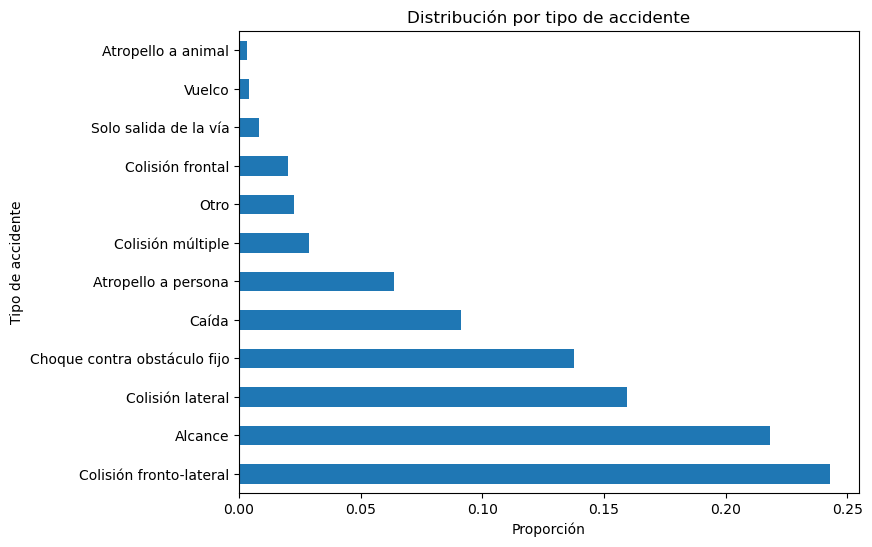

In [115]:
# Normalizar y ver en grafica los valores de las categorias 'tipo_accidente'
db_expediente.tipo_accidente.value_counts(normalize=True).plot.barh()
plt.xlabel('Proporción')
plt.ylabel('Tipo de accidente')
plt.title('Distribución por tipo de accidente')
plt.show()

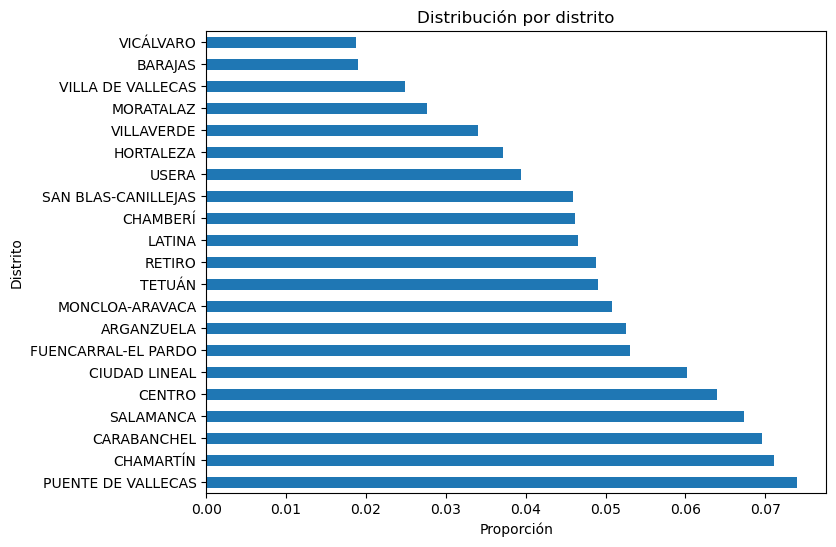

In [116]:
# Normalizar y ver en grafica los valores de las categorias 'distrito'
db_expediente.distrito.value_counts(normalize=True).plot.barh()
plt.xlabel('Proporción')
plt.ylabel('Distrito')
plt.title('Distribución por distrito')
plt.show()

En el caso de los distritos también se ha usado el `db_expediente`, para no contabilizar de forma errada, ya que un accidente muchas veces están implicados más de un vehículo.

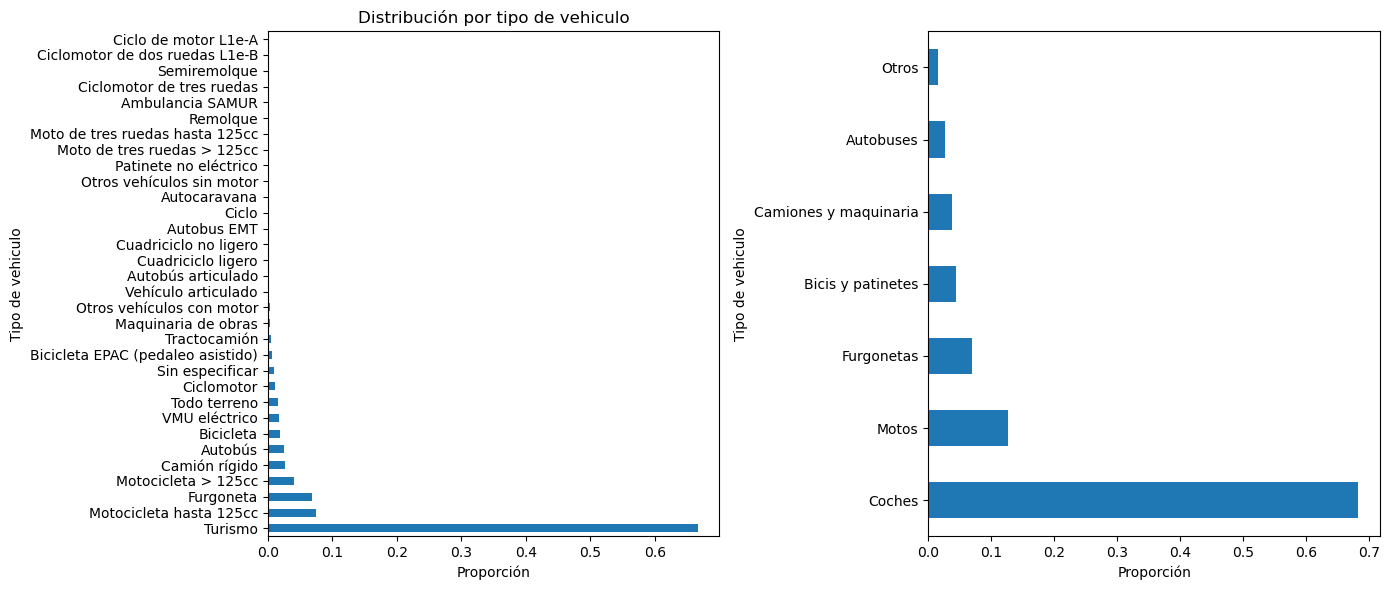

In [118]:
# Graficas: 1 fila, 2 columnas 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Normalizar y graficar los valores de las categorias 'tipo_vehiculo'
db_sin_pasajeros.tipo_vehiculo.value_counts(normalize=True).plot.barh(ax=axes[0])
axes[0].set_xlabel('Proporción')
axes[0].set_ylabel('Tipo de vehiculo')
axes[0].set_title('Distribución por tipo de vehiculo')

# Normalizar y graficar los valores de las categorias 'tipo_vehiculo_grupo'
db_sin_pasajeros.tipo_vehiculo_grupo.value_counts(normalize=True).plot.barh(ax=axes[1])
axes[1].set_xlabel('Proporción')
axes[1].set_ylabel('Tipo de vehiculo')

plt.tight_layout()
plt.show()

Para facilitar la visualización, mostramos juntas dos gráficas: una con la distribución original de los tipos de vehículo del dataset y otra con los grupos simplificados que hemos creado.
El diccionario `mapa_vehiculos` detalla cómo se han agrupado las categorías originales en estos nuevos grupos.

Gracias a esta visualización conjunta, podemos observar con mayor claridad que el grupo de coches es, con diferencia, el que concentra la mayor proporción de accidentes, representando casi el 70% del total.

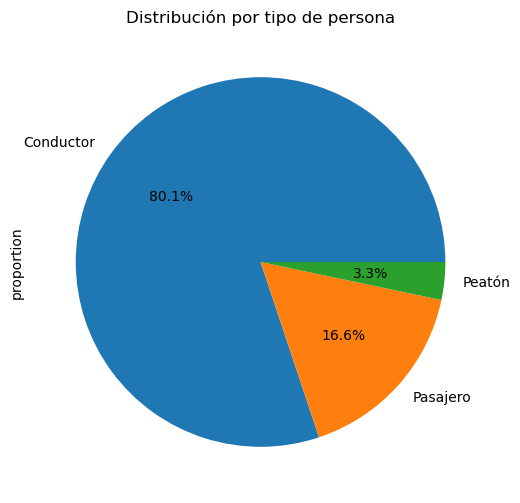

In [120]:
# Normalizar y ver en grafica los valores de las categorias 'tipo_persona'
db.tipo_persona.value_counts(normalize=True).plot.pie(autopct='%1.1f%%')
plt.title('Distribución por tipo de persona')
plt.show()

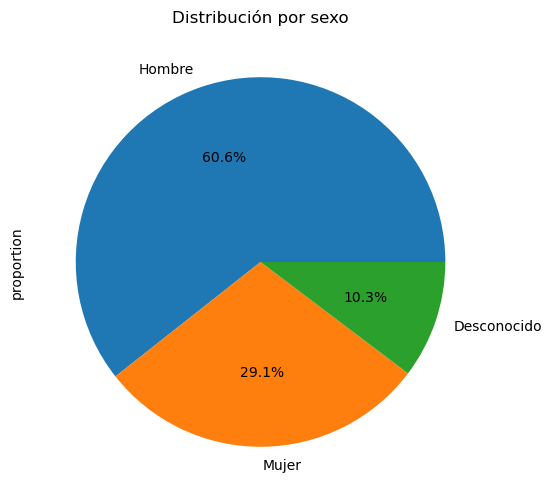

In [121]:
# Normalizar y ver en grafica los valores de las categorias 'sexo'
db.sexo.value_counts(normalize=True).plot.pie(autopct='%1.1f%%')
plt.title('Distribución por sexo')
plt.show()

Para poder ver el gráfico de la columna `rango_edad` de forma ordenada, lo haremos de forma manual.

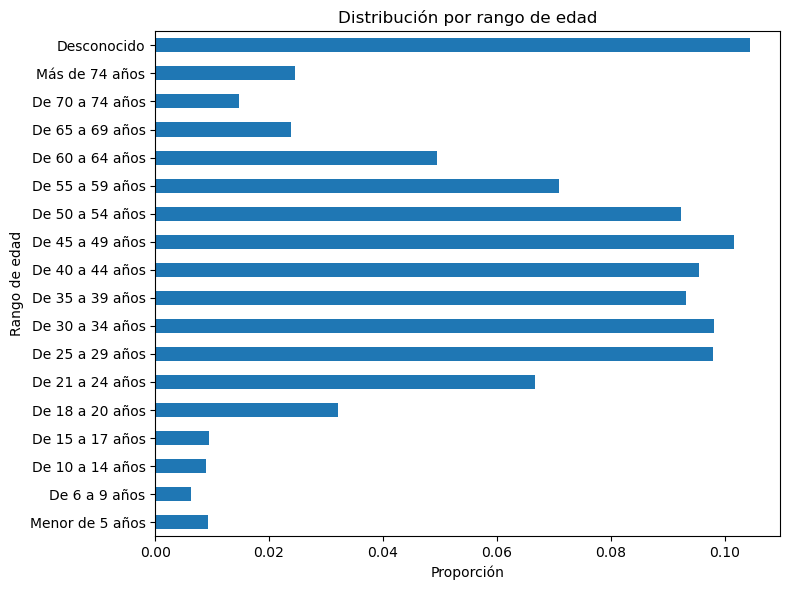

In [123]:
# Listar con el orden correcto de rangos de edad
orden_edad = [
    'Menor de 5 años', 'De 6 a 9 años', 'De 10 a 14 años', 'De 15 a 17 años',
    'De 18 a 20 años', 'De 21 a 24 años', 'De 25 a 29 años', 'De 30 a 34 años',
    'De 35 a 39 años', 'De 40 a 44 años', 'De 45 a 49 años', 'De 50 a 54 años',
    'De 55 a 59 años', 'De 60 a 64 años', 'De 65 a 69 años', 'De 70 a 74 años',
    'Más de 74 años', 'Desconocido'
]

# Convertir la columna a tipo categórico con ese orden
db['rango_edad'] = pd.Categorical(db['rango_edad'], categories=orden_edad, ordered=True)

# Normalizar y graficar
db['rango_edad'].value_counts(normalize=True, sort=False).plot.barh()
plt.xlabel('Proporción')
plt.ylabel('Rango de edad')
plt.title('Distribución por rango de edad')
plt.tight_layout()
plt.show()

Se puede apreciar una cierta campana de Gauss, donde la mayor parte de accidentes se centra de los 18 a los 69. Coincide con las edades legales para conducir en España, al hser una exploración univariante no podemos ver cuantos de ellos son conductores o pasajero.

Dentro de estos rangos, el rango de 25 a 54 años es el que tiene más accidentes.

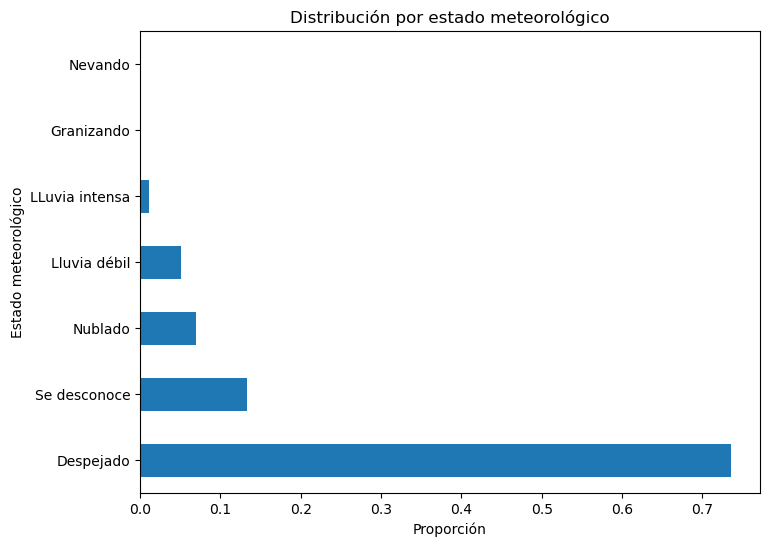

In [125]:
# Normalizar y ver en grafica los valores de las categorias 'estado_meteorologico'
db_expediente.estado_meteorológico.value_counts(normalize=True).plot.barh()
plt.xlabel('Proporción')
plt.ylabel('Estado meteorológico')
plt.title('Distribución por estado meteorológico')
plt.show()

Los estados meteorológicos como nieve o granizo apenas aparecen en los registros, algo coherente con la climatología de Madrid, donde estos fenómenos son poco frecuentes. En cambio, más del 70 % de los accidentes se producen en días despejados, lo que indica que la mayoría de siniestros no están asociados a condiciones meteorológicas adversas.

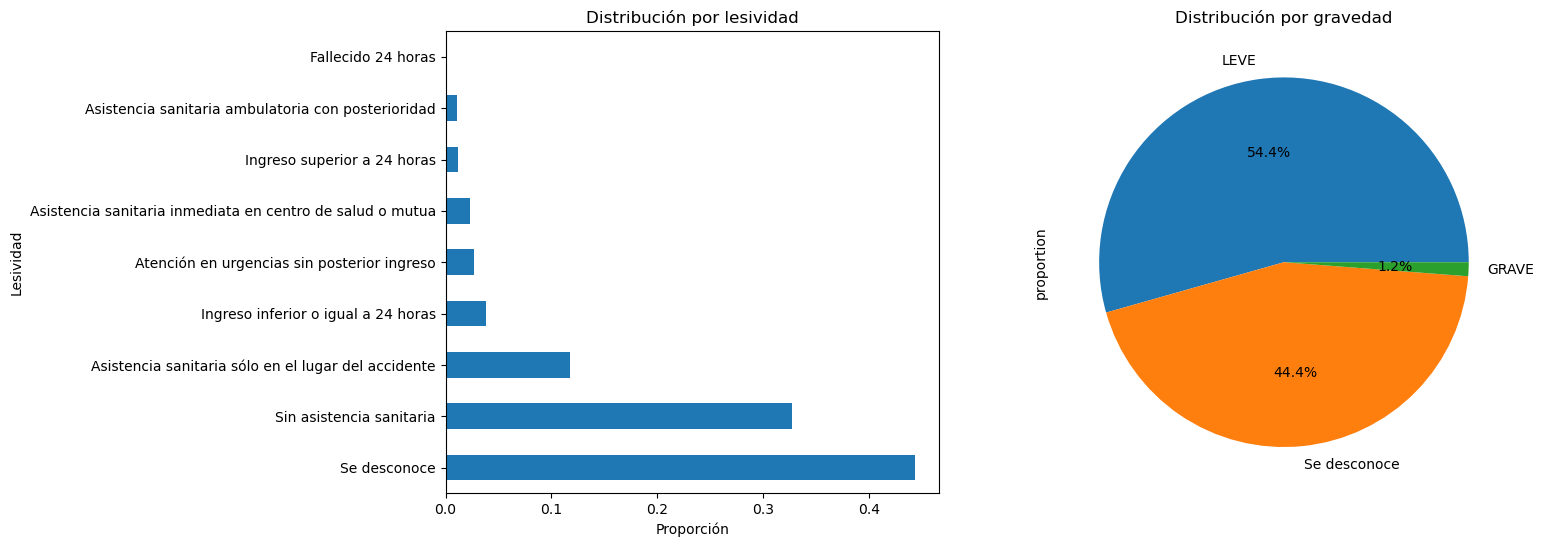

In [127]:
# Graficas: 1 fila, 2 columnas 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Normalizar y ver en grafica los valores de las categorias 'lesividad'
db.lesividad.value_counts(normalize=True).plot.barh(ax=axes[0])
axes[0].set_xlabel('Proporción')
axes[0].set_ylabel('Lesividad')
axes[0].set_title('Distribución por lesividad')

# Normalizar y ver en grafica los valores de las categorias 'acc_grave'
db.acc_grave.value_counts(normalize=True).plot.pie(autopct='%1.1f%%', ax=axes[1])
axes[1].set_title('Distribución por gravedad')

plt.show()

La distribución de lesividad se puede ver perfectamente en la gráfica de barras, pero en la grafica de 'pie' se puede puede ver que los accidentes graves no superan el 2% del total, siendo un 1.2%.

En general hasta ahora podemos ver que la mayor parte de los accidentes fueron de colisión fronto-laterial, en conductores hombres, clima despejado, en un turismo y accidentes leves.

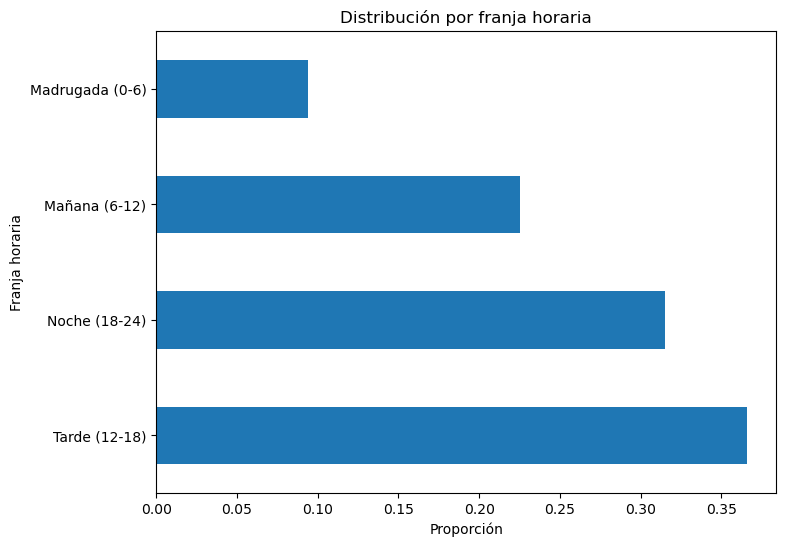

In [129]:
db.franja_horaria.value_counts(normalize=True).plot.barh()
plt.xlabel('Proporción')
plt.ylabel('Franja horaria')
plt.title('Distribución por franja horaria')
plt.show()

Con el análisis univariante de las franjas horarias podemos ver que la tarde es cuando hay más cantidad de accidentes, pero sin información de la lesividad de estos. Para esto se realizará el análisis bivariante más adelante.

A continuación haremos el **análisis univariante de variables numéricas**.

Primeramente vamos a ver el histograma de la columna de horas (hora_int)

<Axes: xlabel='hora_int', ylabel='Count'>

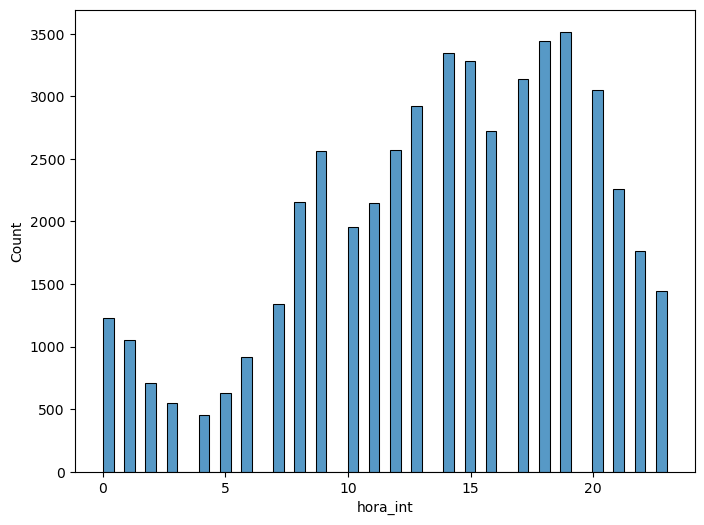

In [131]:
sns.histplot(db.sort_values(by='hora_int', ascending=True)['hora_int'])

Al visualizar el gráfico, observamos que la franja horaria con mayor número de accidentes se concentra entre las 12 h y las 20h, coincidiendo en horas de entrada y salido laboral, escolar.

No obstante, al agrupar las horas en franjas tan amplias estamos perdiendo parte de la información detallada. Por ello, a continuación visualizaremos directamente la variable hora, ajustando el número de bins para obtener una representación más informativa y de fácil interpretación.

C:\Users\paula\AppData\Local\Temp\ipykernel_6772\470396915.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  db['hora_float'] = pd.to_datetime(db['hora']).dt.hour + pd.to_datetime(db['hora']).dt.minute/60
C:\Users\paula\AppData\Local\Temp\ipykernel_6772\470396915.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  db['hora_float'] = pd.to_datetime(db['hora']).dt.hour + pd.to_datetime(db['hora']).dt.minute/60


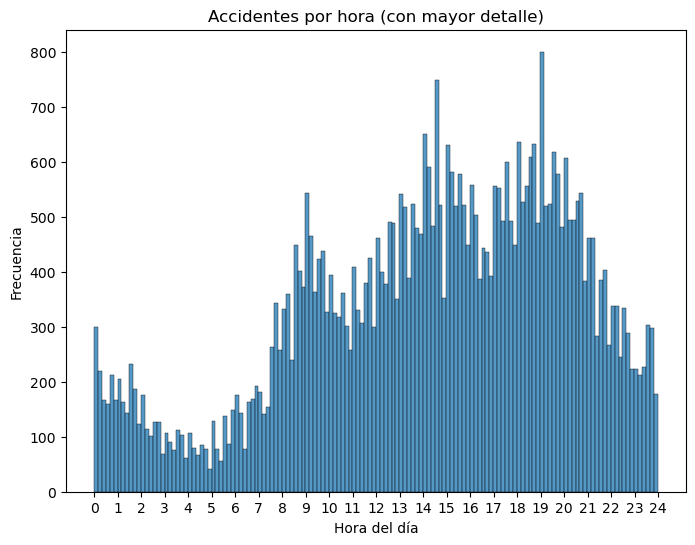

In [133]:
db['hora_float'] = pd.to_datetime(db['hora']).dt.hour + pd.to_datetime(db['hora']).dt.minute/60

#Limitar los bins a 144
sns.histplot(db['hora_float'], bins=144)  # más barras

plt.xticks(range(0, 25))
plt.xlabel("Hora del día")
plt.ylabel("Frecuencia")
plt.title("Accidentes por hora (con mayor detalle)")
plt.grid(False)
plt.show()


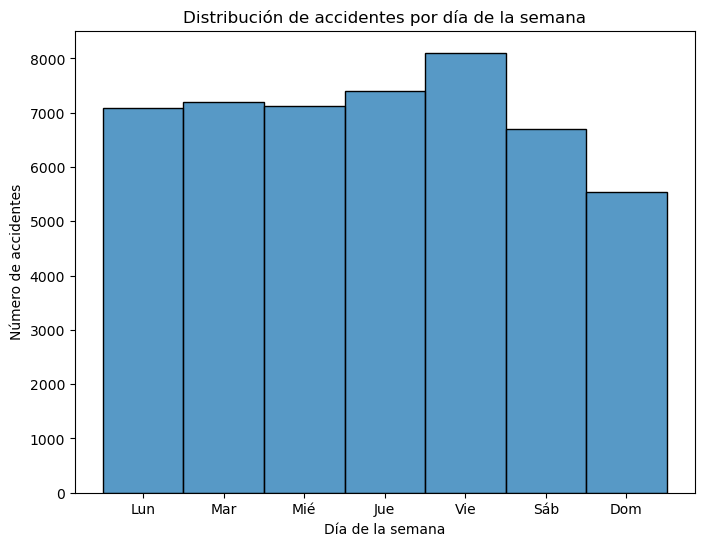

In [134]:
sns.histplot(db, x='dia_sem', discrete=True)
plt.xticks(range(0, 7), ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom'])
plt.xlabel("Día de la semana")
plt.ylabel("Número de accidentes")
plt.title("Distribución de accidentes por día de la semana")
plt.show()


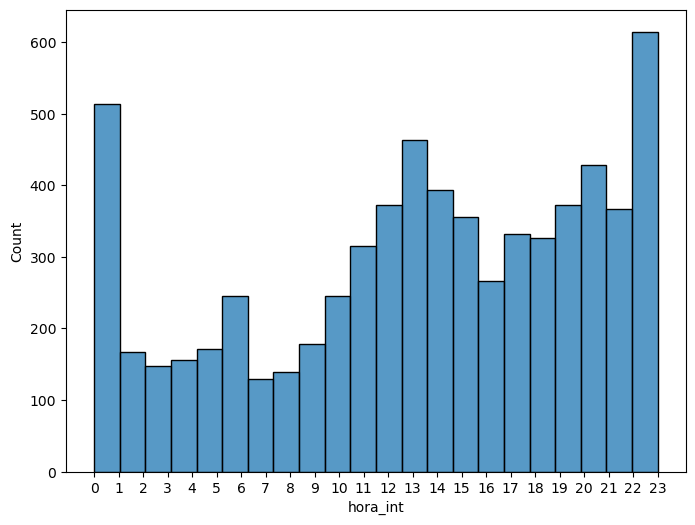

In [135]:
sns.histplot(db[db['dia_sem']==5].sort_values(by='hora_int', ascending=True)['hora_int'])
plt.xticks(range(0, 24))
plt.show()

Los viernes son el día de la semana con mayor número de siniestros. Al analizar la distribución horaria de los accidentes ocurridos en viernes, se observa un pico entre las 23:00 y la 01:00, coincidiendo con las horas asociadas a la vida nocturna.

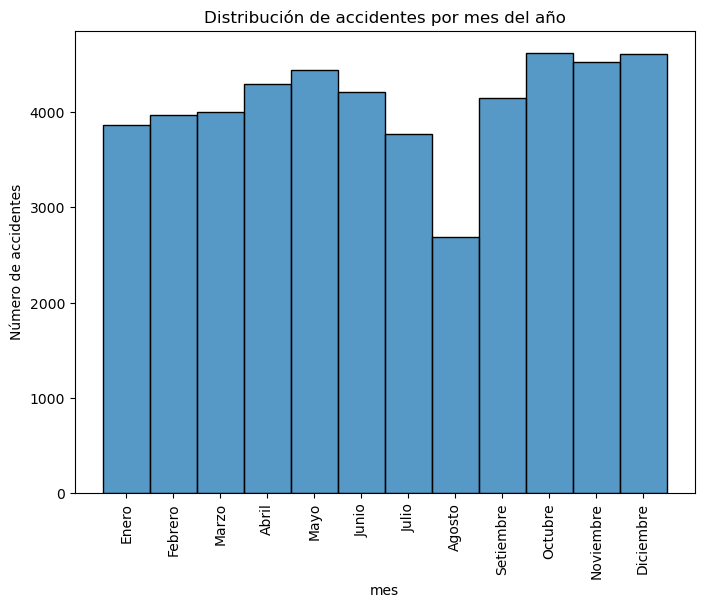

In [137]:
sns.histplot(db, x='mes', discrete=True)
plt.xticks(range(1, 13), ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Setiembre', 'Octubre', 'Noviembre', 'Diciembre'], rotation=90)
plt.ylabel("Número de accidentes")
plt.title("Distribución de accidentes por mes del año")
plt.show()

La distribución mensual muestra una disminución del número de accidentes durante los meses de verano, especialmente en julio y agosto. Este comportamiento es coherente con una reducción de la movilidad urbana asociada al periodo vacacional y a la disminución de los desplazamientos laborales habituales. No se observan indicios que apunten a un sesgo de registro estacional, por lo que el patrón se interpreta como un efecto real y no como una limitación del conjunto de datos

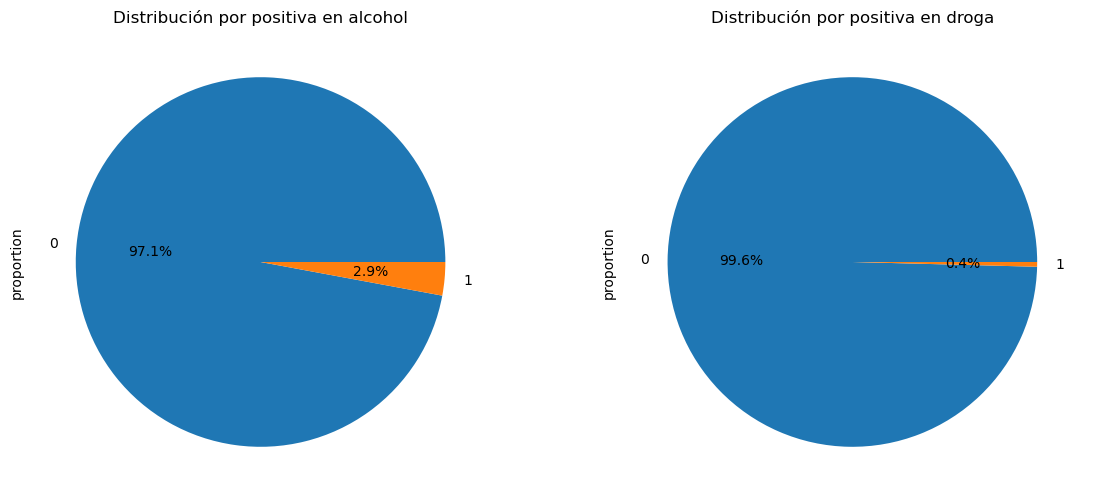

In [139]:
# Graficas: 1 fila, 2 columnas 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Normalizar y ver en grafica los valores de las categorias 'positiva_alcohol'
db.positiva_alcohol.value_counts(normalize=True).plot.pie(autopct='%1.1f%%', ax=axes[0])
axes[0].set_title('Distribución por positiva en alcohol')

# Normalizar y ver en grafica los valores de las categorias 'positiva_droga'
db.positiva_droga.value_counts(normalize=True).plot.pie(autopct='%1.1f%%', ax=axes[1])
axes[1].set_title('Distribución por positiva en droga')

plt.show()

### Análisis Bivariante

Ahora pasamos al **análisis bivariante de variables**, una etapa clave para identificar relaciones relevantes entre los datos. Este paso nos permitirá descubrir patrones y obtener evidencias que servirán de base para un estudio sólido y conclusiones fundamentadas.

#### ¿Qué tipo de accidente es el más frecuente en cada distrito?



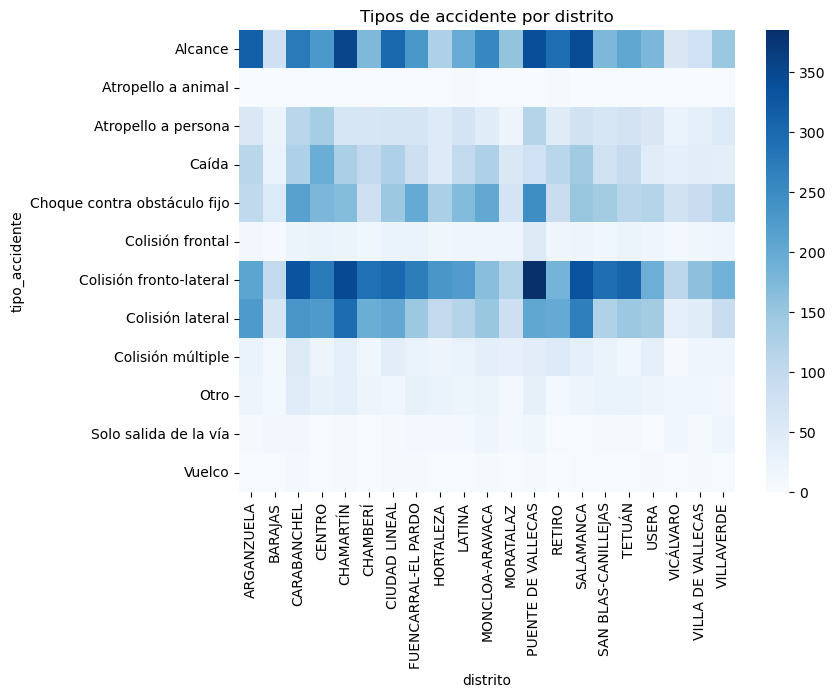

In [141]:
tabla = pd.crosstab(db_expediente["tipo_accidente"], db_expediente["distrito"])
sns.heatmap(tabla, cmap="Blues", annot=False)
plt.title("Tipos de accidente por distrito")
plt.show()

In [142]:
db.groupby('distrito')['tipo_accidente'].agg(lambda x: x.mode()[0])

distrito
ARGANZUELA                             Alcance
BARAJAS                Colisión fronto-lateral
CARABANCHEL            Colisión fronto-lateral
CENTRO                 Colisión fronto-lateral
CHAMARTÍN                              Alcance
CHAMBERÍ               Colisión fronto-lateral
CIUDAD LINEAL                          Alcance
FUENCARRAL-EL PARDO    Colisión fronto-lateral
HORTALEZA              Colisión fronto-lateral
LATINA                 Colisión fronto-lateral
MONCLOA-ARAVACA                        Alcance
MORATALAZ                              Alcance
PUENTE DE VALLECAS     Colisión fronto-lateral
RETIRO                                 Alcance
SALAMANCA                              Alcance
SAN BLAS-CANILLEJAS    Colisión fronto-lateral
TETUÁN                 Colisión fronto-lateral
USERA                  Colisión fronto-lateral
VICÁLVARO              Colisión fronto-lateral
VILLA DE VALLECAS      Colisión fronto-lateral
VILLAVERDE             Colisión fronto-lateral
Name


En el mapa de calor anterior se observa de forma visual qué tipos de accidente son más comunes en cada distrito. Para complementar esta visualización y verificar los resultados de manera más directa, realizamos una agrupación que nos permita identificar explícitamente el tipo de accidente más frecuente en cada distrito.

Este enfoque nos permite combinar la interpretación visual con un indicador cuantitativo, asegurando consistencia entre ambas perspectivas.

#### ¿Existen diferencias en la positividad en alcohol según el sexo de la persona implicada?

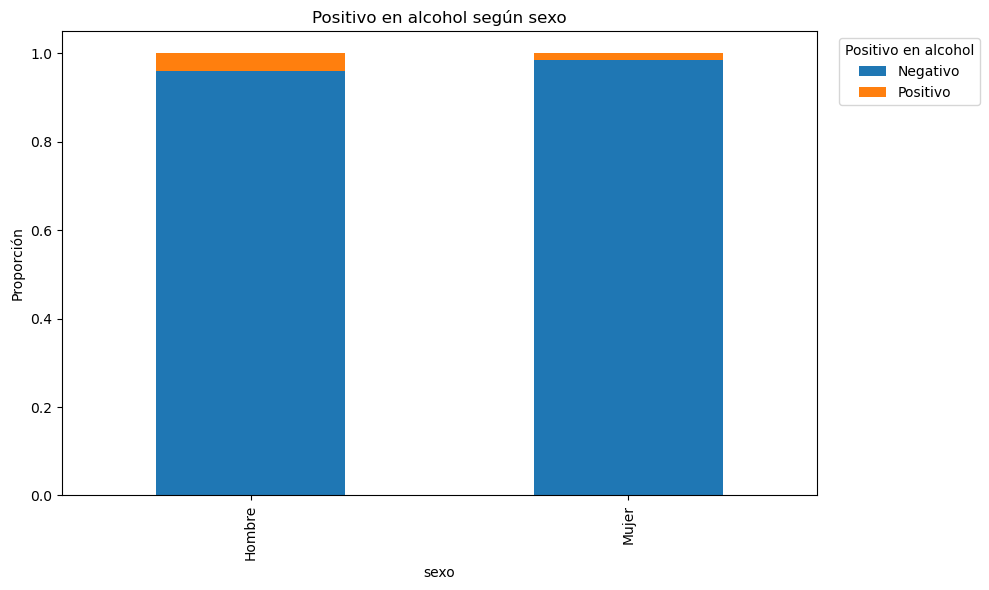

In [144]:
# Para poder ver bien la gráfica, vamos a visualizarla sin la categoria 'se desconoce' de la columna 'acc_grave'
db_filtro = db[db['sexo'] != 'Desconocido']

# Representamos la tabla de contingencia mediante un gráfico de barras apiladas para visualizar de forma clara la relación bivariante entre ambas variables
tab = pd.crosstab(db_filtro['sexo'], db_filtro['positiva_alcohol'], normalize='index')

# Poner nombres 
tab = tab.rename(columns={0: "Negativo", 1: "Positivo"})

# Configurar la tabla
ax = tab.plot(kind='bar', stacked=True, figsize=(10,6))
plt.ylabel("Proporción")
plt.title("Positivo en alcohol según sexo")

# Mover la leyenda fuera del gráfico
ax.legend(
    title="Positivo en alcohol",
    bbox_to_anchor=(1.02, 1),   
    loc='upper left'
)

plt.tight_layout()
plt.show()


In [145]:
# Obtener el porcentaje desde la gráfica
tab = pd.crosstab(db_filtro['sexo'], db_filtro['positiva_alcohol'], normalize='index')
porcentaje_hombre = tab.loc['Hombre', 1] * 100
porcentaje_mujer = tab.loc['Mujer', 1] * 100

print("Hombres positivos alcohol:", round(porcentaje_hombre, 2), "%")
print("Mujeres positivas alcohol:", round(porcentaje_mujer, 2), "%")


Hombres positivos alcohol: 4.06 %
Mujeres positivas alcohol: 1.55 %


Los resultados muestran que la proporción de conductores que dieron positivo en alcohol es mayor en hombres (**4.06%**) que en mujeres (**1.55%**), lo que indica que, en los accidentes de tráfico, es más común encontrar casos de consumo de alcohol entre hombres que entre mujeres.

#### ¿Se observa que los accidentes que ocurren en la madrugada (por ejemplo, 00:00-06:00) tienen mayor incidencia de positividad en alcohol?

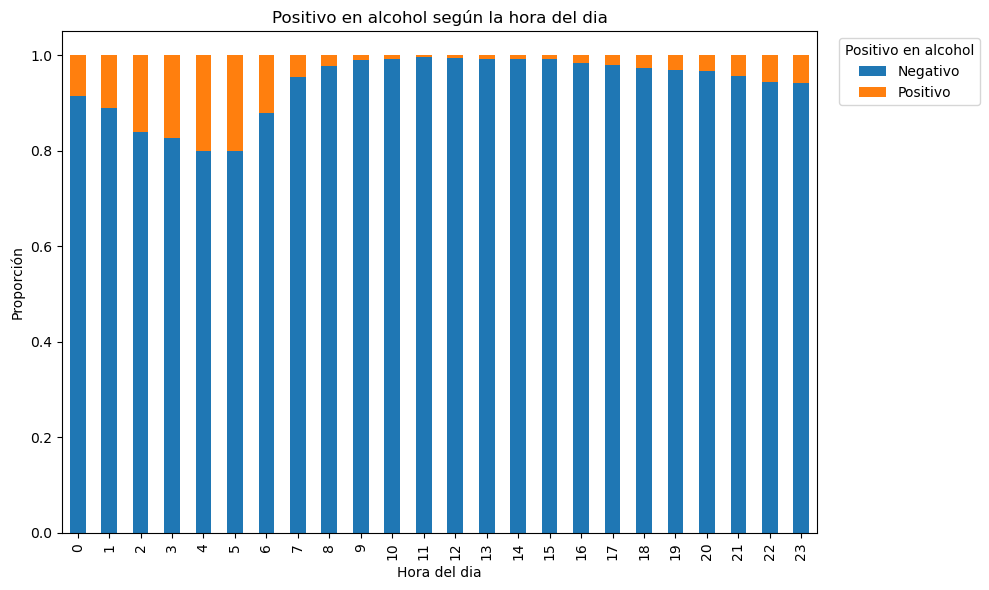

In [147]:
# Representamos la tabla de contingencia mediante un gráfico de barras apiladas para visualizar de forma clara la relación bivariante entre ambas variables
tab = pd.crosstab(db_filtro['hora_int'], db_filtro['positiva_alcohol'], normalize='index')

# Poner nombres 
tab = tab.rename(columns={0: "Negativo", 1: "Positivo"})

# Configurar la tabla
ax = tab.plot(kind='bar', stacked=True, figsize=(10,6))
plt.ylabel("Proporción")
plt.xlabel("Hora del dia")
plt.title("Positivo en alcohol según la hora del dia")

# Mover la leyenda fuera del gráfico
ax.legend(
    title="Positivo en alcohol",
    bbox_to_anchor=(1.02, 1),   
    loc='upper left'
)

plt.tight_layout()
plt.show()

La mayor proporción de positivos en alcohol se concentra entre las 0:00 y las 6:00 de la mañana, con un pico especialmente notable alrededor de las 2:00–5:00 horas. Esto resulta coherente con las horas de salida de locales nocturnos y actividades de ocio, donde el consumo de alcohol es más frecuente.

#### ¿En qué tipos de accidente se da más frecuencia de positivos en alcohol?

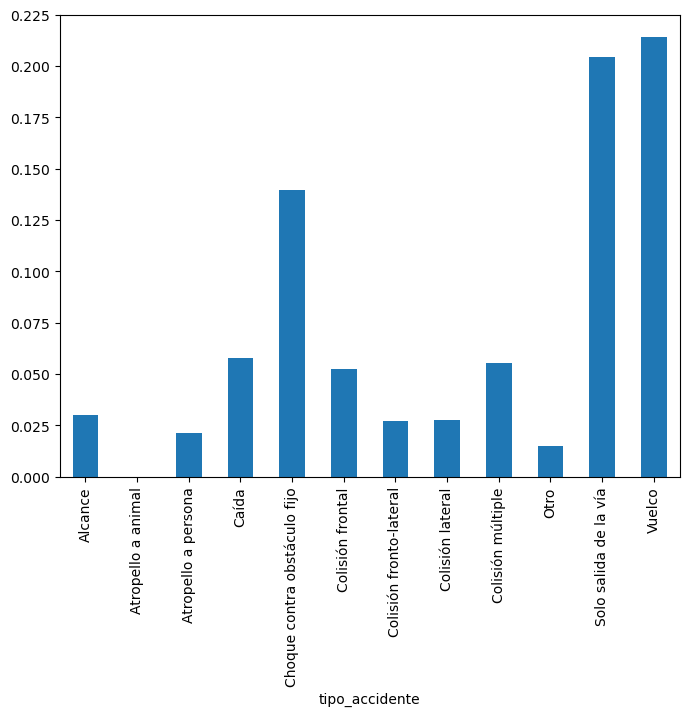

In [149]:
db_expediente.groupby('tipo_accidente', observed=True)['positiva_alcohol'].mean().plot.bar()
plt.show()

La mayor frecuencia de positivos en alcohol se concentra en accidentes que implican pérdida de control del vehículo, como vuelcos, salidas de la vía y choques contra un obstáculo fijo. Esto sugiere que el consumo de alcohol puede afectar la capacidad del conductor para mantener el control del vehículo.

#### ¿Existen diferencias notables en los accidentes implicando peatones según el distrito?

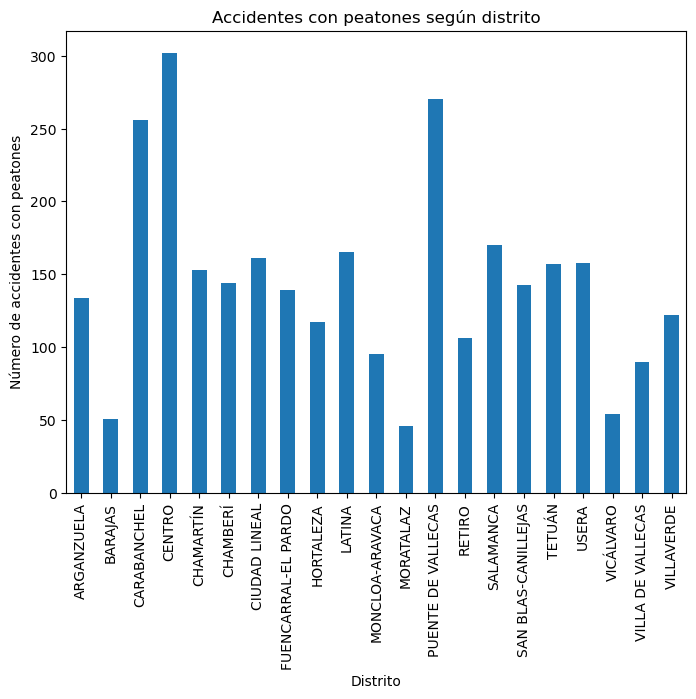

In [151]:
# Filtrar el dataset para accidentes a peatones (atropello a persona)
db_peaton = db[db['tipo_accidente'] == 'Atropello a persona']

# Graficar con los nombres de los distritos ordenados alfabeticamente
# Para hacer el código más visual lo haremos con encadenamiento de métodos
(
    db_peaton['distrito']
    .value_counts()
    .sort_index()
    .plot.bar()
)
plt.xlabel("Distrito")
plt.ylabel("Número de accidentes con peatones")
plt.title("Accidentes con peatones según distrito")
plt.show()

Existen diferencias notables en los accidentes implicando peatones en los distritos de Carabanchel, Centro y Puente de Vallecas. Vamos a realizar un analisis más profundo dentro en estos tres distritos.

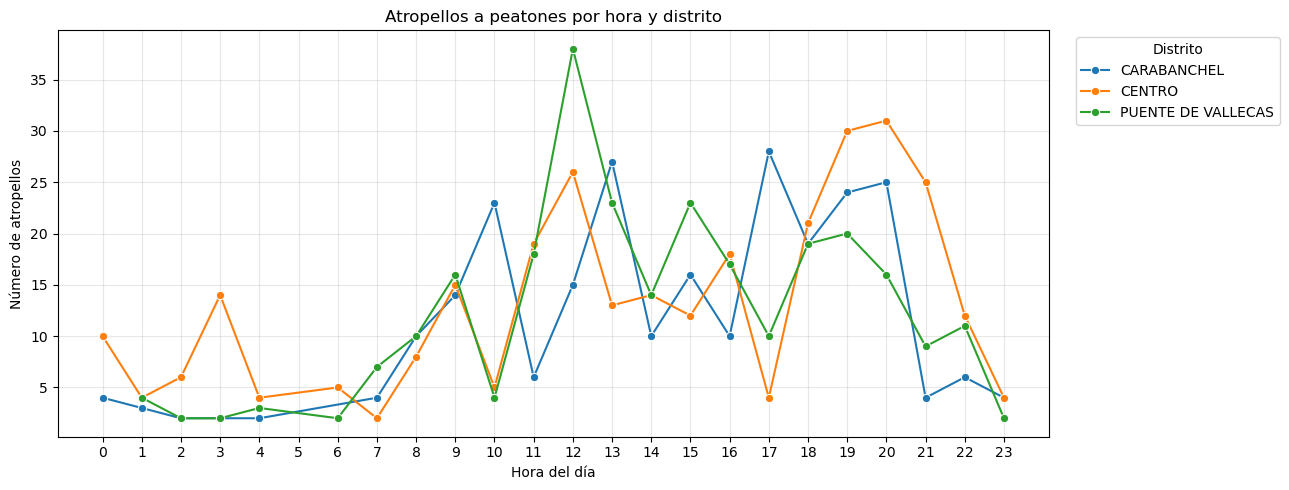

In [153]:
# Elegir los distritos que tienen más atropellos a peatones
distritos_interes = ['CARABANCHEL', 'CENTRO', 'PUENTE DE VALLECAS']  
db_distritos_sel = db_peaton[db_peaton['distrito'].isin(distritos_interes)]

# Agrupar por hora y distrito y contar atropellos
datos = (
    db_distritos_sel
    .groupby(['hora_int', 'distrito'])
    .size()
    .reset_index(name='n_atropellos')
)

plt.figure(figsize=(13,5))
sns.lineplot(data=datos, x='hora_int', y='n_atropellos', hue='distrito', marker='o')

plt.xticks(range(0, 24))
plt.xlabel("Hora del día")
plt.ylabel("Número de atropellos")
plt.title("Atropellos a peatones por hora y distrito")
plt.grid(alpha=0.3)
plt.legend(title="Distrito", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

El análisis muestra que los distritos de Carabanchel, Puente de Vallecas y Centro registran un número significativamente mayor de atropellos a peatones, aunque por razones distintas:

- Carabanchel y Puente de Vallecas son distritos que combinan zonas interiores con calles estrechas y alta densidad residencial, junto con avenidas de mucho tráfico. La movilidad diaria, especialmente los desplazamientos laborales, genera un volumen importante de peatones y vehículos durante las horas punta. Esto explica que los picos de atropellos aparezcan en horas que coincidien con las franjas típicas de ida y vuelta del trabajo.

- El distrito Centro, además de los residentes, existe un flujo muy alto de turistas, trabajadores del sector servicios y ocio nocturno. Por ello, el patrón es distinto, hay repuntes en las horas punta laborales, pero también de madrugada, coincidiendo con la actividad nocturna. Es un distrito donde peatones y vehículos interactúan continuamente, lo que naturalmente aumenta la probabilidad de incidentes.

Los tres distritos comparten una alta intensidad peatonal y un tráfico elevado, factores que incrementan la exposición al riesgo.

#### ¿Qué franja horaria concentra mayor número de atropellos a personas?

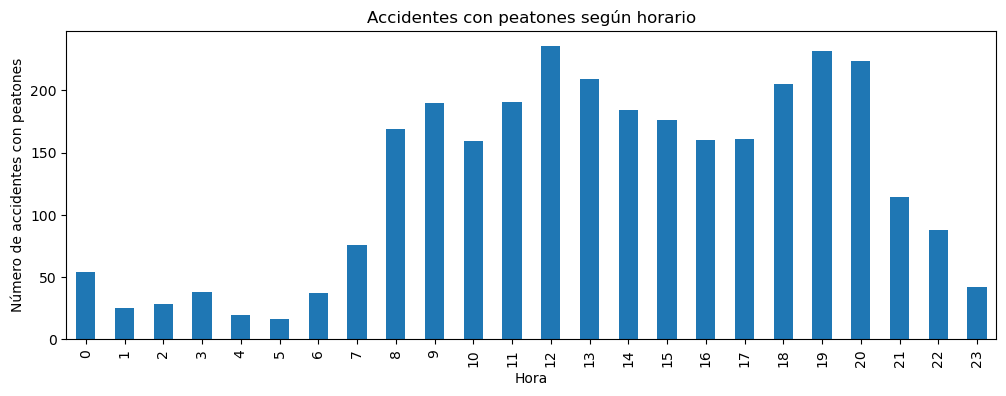

In [155]:
# Filtrar el dataset para accidentes a peatones (atropello a persona)
db_peaton = db[db['tipo_accidente'] == 'Atropello a persona']

# Graficar 
plt.figure(figsize=(12,4))
(
    db_peaton['hora_int']
    .value_counts()
    .sort_index()
    .plot.bar()
)
plt.xlabel("Hora")
plt.ylabel("Número de accidentes con peatones")
plt.title("Accidentes con peatones según horario")
plt.show()

Los atropellos a peatones se concentran principalmente en las horas punta, especialmente entre las **8:00 y las 14:00**, y otro repunte entre las **18:00 y las 20:00**. Este patrón coincide con los momentos de mayor movilidad por motivos laborales, escolares y de actividades diarias.

En contraste, durante la madrugada los atropellos disminuyen de forma notable, algo esperable debido a la baja presencia tanto de peatones como de vehículos en la vía pública.

#### ¿Que rango de edad es el que sufre más accidentes por atropello?

Text(0, 0.5, '')

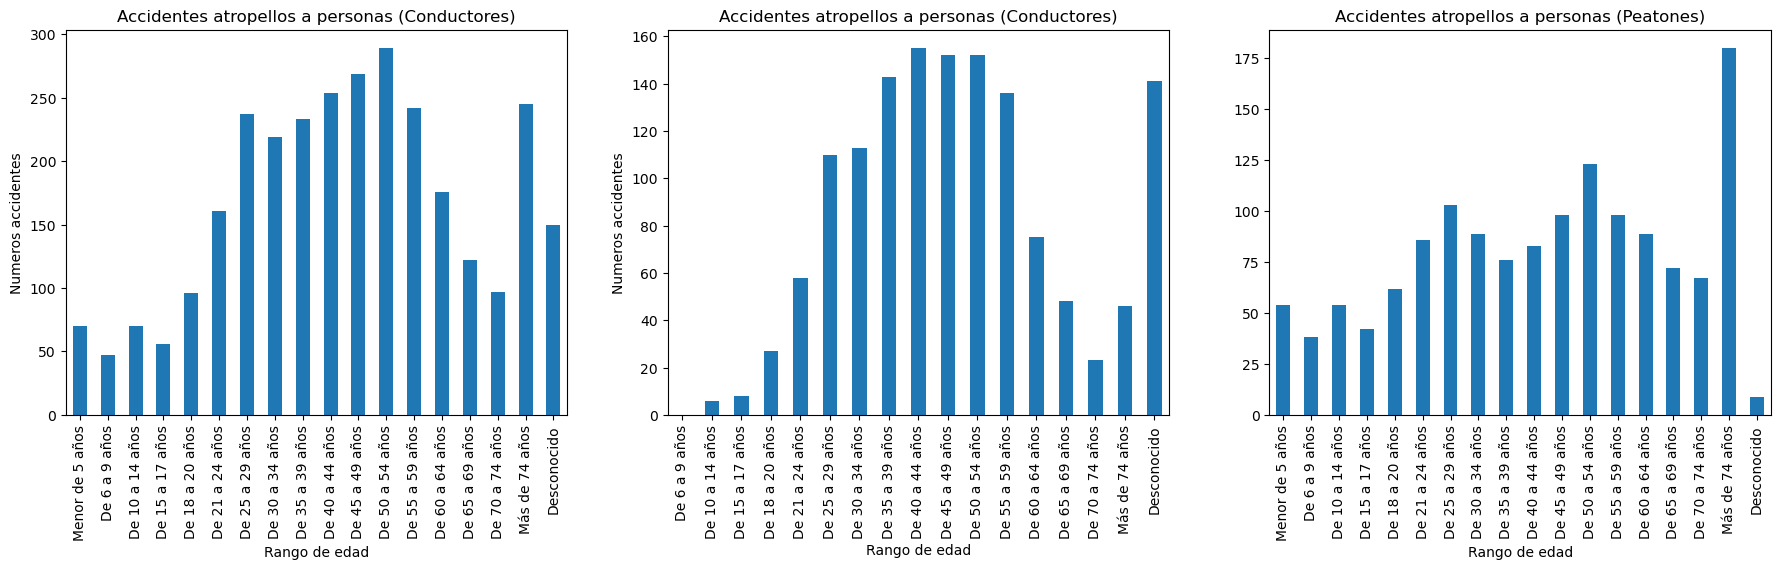

In [157]:
# Graficas: 1 fila, 2 columnas
fig, axes = plt.subplots(1, 3, figsize=(22, 5))

pd.crosstab(
    db['tipo_accidente'],
    db['rango_edad']
).loc['Atropello a persona'].plot.bar(ax=axes[0])

axes[0].set_title("Accidentes atropellos a personas (Conductores)")
axes[0].set_xlabel("Rango de edad")
axes[0].set_ylabel("Numeros accidentes")

db_conductores = db[db['tipo_persona'] == 'Conductor']

pd.crosstab(
    db_conductores['tipo_accidente'],
    db_conductores['rango_edad']
).loc['Atropello a persona'].plot.bar(ax=axes[1])

axes[1].set_title("Accidentes atropellos a personas (Conductores)")
axes[1].set_xlabel("Rango de edad")
axes[1].set_ylabel("Numeros accidentes")

db_peaton = db[db['tipo_persona'] == 'Peatón']

pd.crosstab(
    db_peaton['tipo_accidente'],
    db_peaton['rango_edad']
).loc['Atropello a persona'].plot.bar(ax=axes[2])

axes[2].set_title("Accidentes atropellos a personas (Peatones)")
axes[2].set_xlabel("Rango de edad")
axes[2].set_ylabel("")


En el análisis global de los atropellos a personas se observa un aumento progresivo del número de accidentes en los rangos de edad comprendidos entre los 21 y los 64 años, así como un pico destacado en el grupo de mayores de 74 años. 

Al analizar exclusivamente los conductores implicados en atropellos, se observa que el mayor número de casos se concentra en los rangos de edad entre los 25 y los 59 años, coincidiendo con edades de mayor actividad y exposición a la conducción. 

Por el contrario, en el caso de los peatones, los atropellos se concentran principalmente en los rangos de edad más avanzados, especialmente en personas mayores de 74 años, lo que resulta coherente con una mayor vulnerabilidad y menor capacidad de reacción ante el tráfico.

#### ¿En qué meses del año (o estaciones) se produce un mayor número de accidentes?

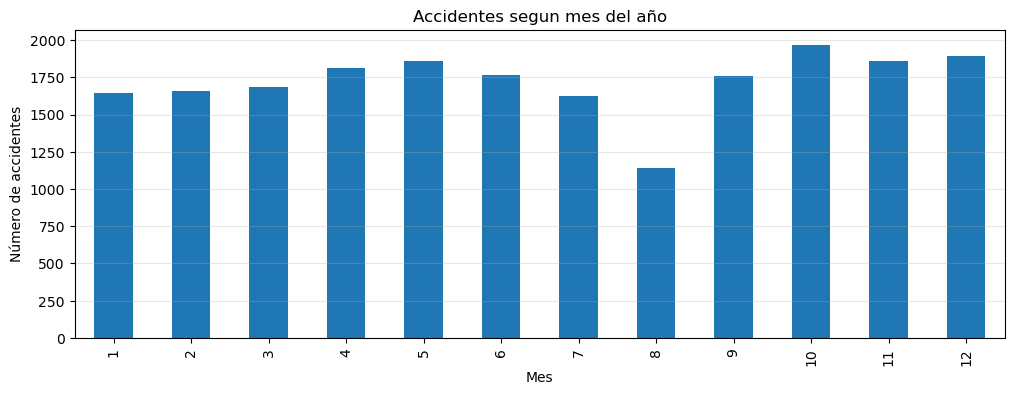

In [160]:
# Graficar 
plt.figure(figsize=(12,4))

(
    db_expediente['mes']
    .value_counts()
    .sort_index() # ordenar 
    .plot.bar()
)

plt.xlabel("Mes")
plt.ylabel("Número de accidentes")
plt.title("Accidentes segun mes del año")
plt.grid(axis='y', alpha=0.3)
plt.show()

Podemos observar que los meses con mayor número de accidentes son abril, mayo, junio, septiembre, octubre, noviembre y diciembre, concentrándose especialmente en primavera y otoño.
Estos periodos suelen coincidir con una mayor actividad en la vía pública, más desplazamientos y condiciones meteorológicas favorables, lo que incrementa la exposición al tráfico.

Por el contrario, agosto presenta una reducción notable, probablemente asociada a la menor actividad urbana y a la disminución de desplazamientos por vacaciones.

#### ¿Existe relación entre gravedad del accidente y positivos en alcohol o drogas?


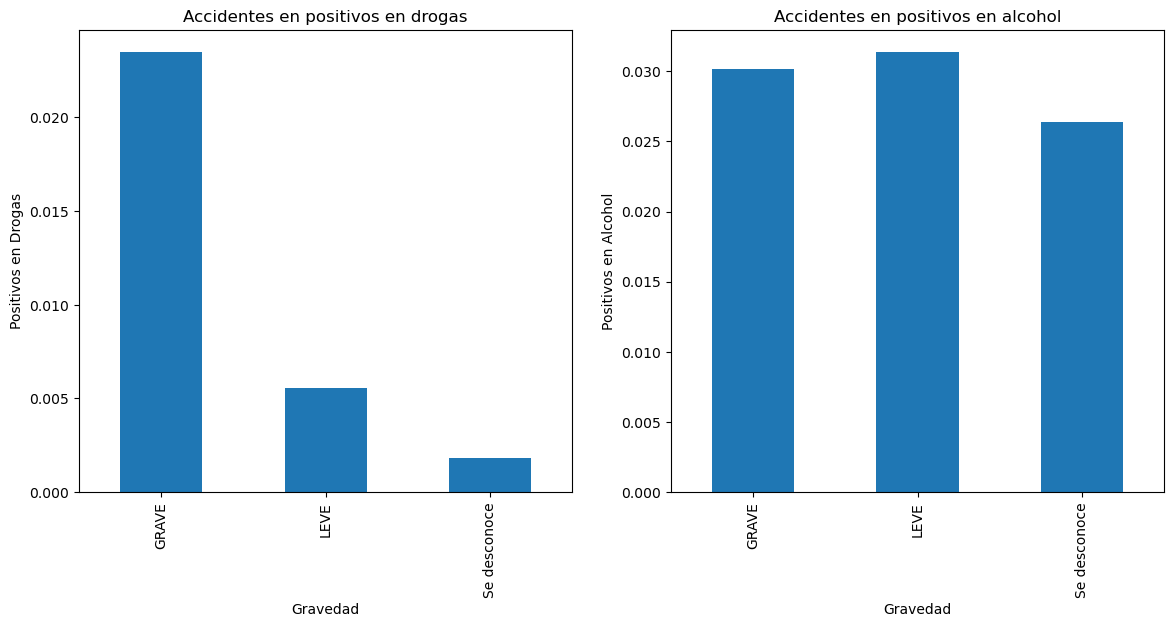

In [162]:
# Graficas: 1 fila, 2 columnas 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Grafica relación positivos droga / gravedad
db.groupby("acc_grave")["positiva_droga"].mean().plot.bar(ax=axes[0])
axes[0].set_ylabel("Positivos en Drogas")
axes[0].set_xlabel("Gravedad")
axes[0].set_title("Accidentes en positivos en drogas")

# Grafica relación positivos alcohol / gravedad
db.groupby('acc_grave')['positiva_alcohol'].mean().plot.bar(ax=axes[1])
axes[1].set_ylabel("Positivos en Alcohol")
axes[1].set_xlabel("Gravedad")
axes[1].set_title("Accidentes en positivos en alcohol")

plt.show()

Aunque existe una pequeña diferencia en la proporción de accidentes graves entre los conductores que dieron positivo en drogas, estas diferencias son muy reducidas (alrededor del 2%), y en el caso de positivo en alcohol los porcentages son exporximadamente los mismo para accidentes graves y leves (alrededor del 3%).

Esto indica que, en este conjunto de datos, el consumo de alcohol o drogas no parece ser un factor determinante en la gravedad del accidente, ya que la mayoría de los accidentes graves se producen sin presencia de sustancias.

#### ¿Existe relación entre el rango de edad de la persona implicada y la gravedad de las lesiones (lesividad)?

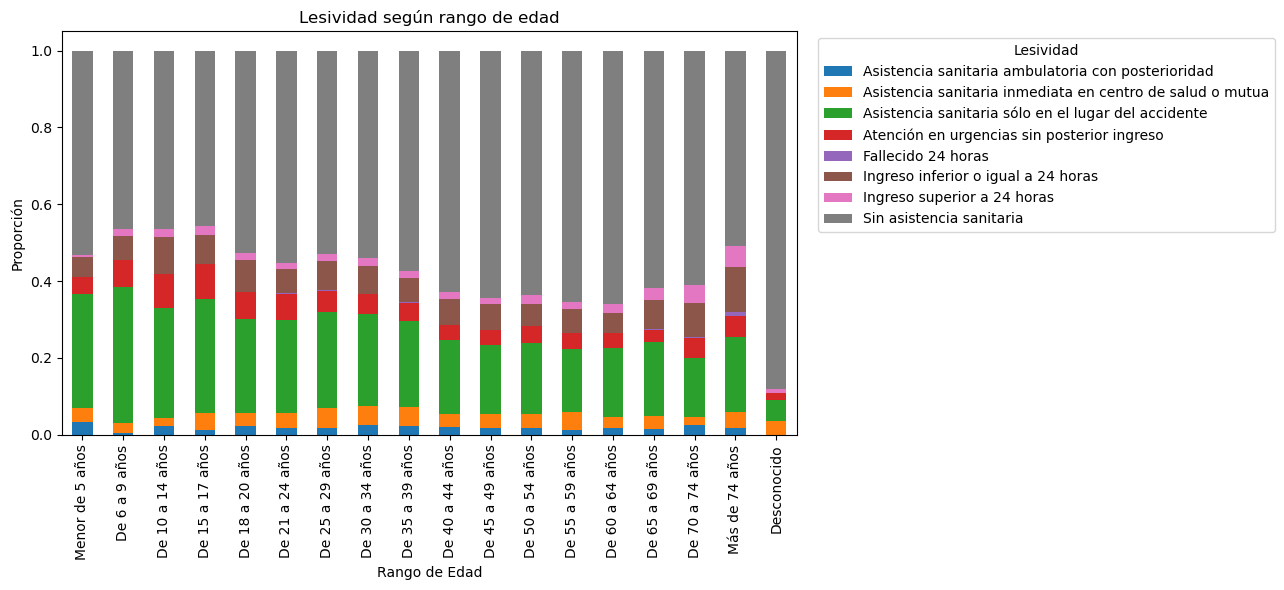

In [164]:
# Para poder ver bien la gráfica, vamos a visualizarla sin la categoria 'se desconoce' de la columna 'lesividad'
db_filto = db[db['lesividad'] != 'Se desconoce']

# Representamos la tabla de contingencia mediante un gráfico de barras apiladas para visualizar de forma clara la relación bivariante entre ambas variables
tab = pd.crosstab(db_filto['rango_edad'], db_filto['lesividad'], normalize='index')
ax = tab.plot(kind='bar', stacked=True, figsize=(13,6))

plt.xlabel("Rango de Edad")
plt.ylabel("Proporción")
plt.title("Lesividad según rango de edad")

# Mover la leyenda fuera del gráfico
ax.legend(
    title="Lesividad",
    bbox_to_anchor=(1.02, 1),   
    loc='upper left'
)

plt.tight_layout()
plt.show()

Dado que este gráfico recoge muchas categorías y resulta difícil identificar patrones claros, analizaremos a continuación la gravedad del accidente (`acc_grave`), que nos ofrece una medida más directa de severidad.

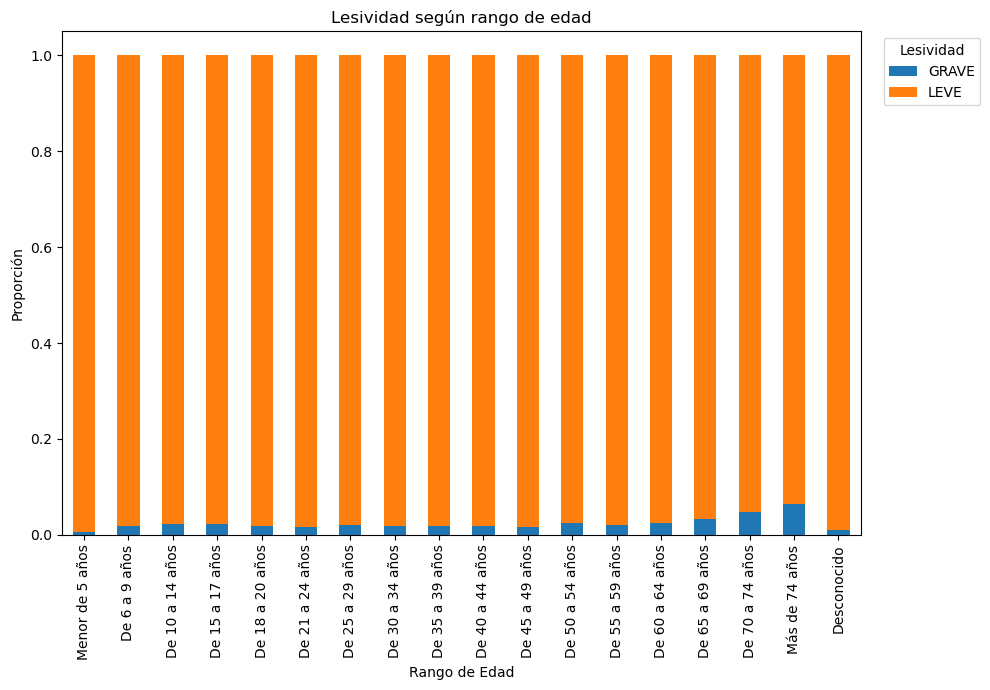

In [166]:
# Para poder ver bien la gráfica, vamos a visualizarla sin la categoria 'se desconoce' de la columna 'acc_grave'
db_filto = db[db['acc_grave'] != 'Se desconoce']

# Representamos la tabla de contingencia mediante un gráfico de barras apiladas para visualizar de forma clara la relación bivariante entre ambas variables
tab = pd.crosstab(db_filto['rango_edad'], db_filto['acc_grave'], normalize='index')
ax = tab.plot(kind='bar', stacked=True, figsize=(10,7))

plt.xlabel("Rango de Edad")
plt.ylabel("Proporción")
plt.title("Lesividad según rango de edad")

# Mover la leyenda fuera del gráfico
ax.legend(
    title="Lesividad",
    bbox_to_anchor=(1.02, 1),   
    loc='upper left'
)

plt.tight_layout()
plt.show()

En esta gráfica obtenemos una visión más directa y simplificada al reducir la variable a dos categorías (grave y leve). No obstante, para visualizar mejor la variación por rango de edad y facilitar la comparación, realizaremos una última representación a partir de una tabla de contingencia (crosstab).

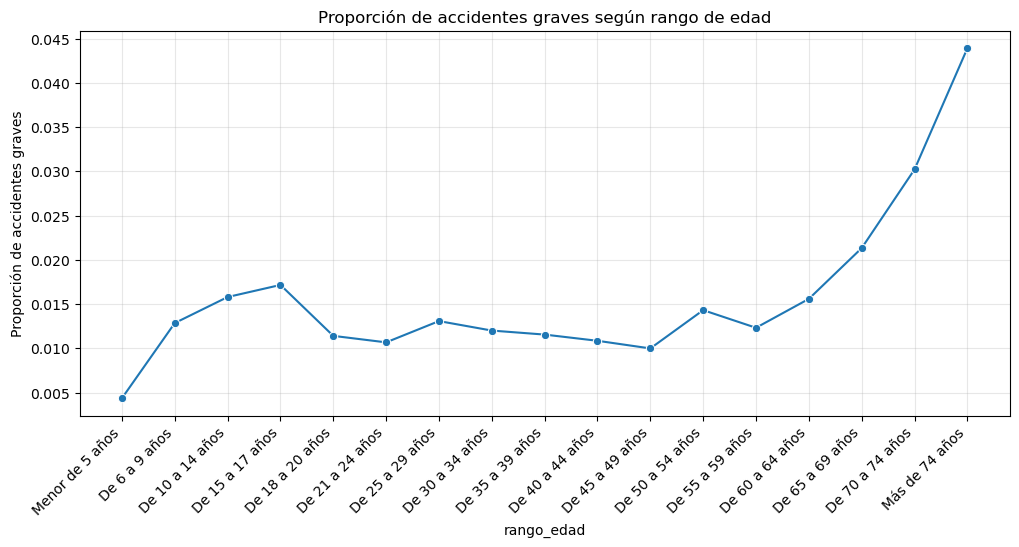

In [168]:
# Crear tabla de contingencia
tab = pd.crosstab(db['rango_edad'], db['acc_grave'], normalize='index')
grave = tab['GRAVE']

# Sacamos la categoria 'Desconocido'
grave = grave.drop("Desconocido")

plt.figure(figsize=(12,5))
sns.lineplot(x=grave.index, y=grave.values, marker='o')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Proporción de accidentes graves")
plt.title("Proporción de accidentes graves según rango de edad")
plt.grid(alpha=0.3)

plt.show()


El patrón más destacado se observa en los rangos de edad más avanzados, a partir de los 65 años, donde la proporción de accidentes graves aumenta de forma clara y sostenida, lo cual resulta coherente debido a su mayor vulnerabilidad física. De manera secundaria, se aprecia un ligero incremento en los grupos de edad más jóvenes, especialmente entre los 14 y 17 años, que coinciden con los primeros permisos de conducir de motocicletas en adolescentes. Por el contrario, en los grupos de edad intermedia la proporción de accidentes graves disminuye, manteniéndose relativamente baja y estable.

#### ¿Se observa alguna relación entre el estado meteorológico y la lesividad de los accidentes?
Para comparar los estados meteorológicos en igualdad de condiciones, realizamos el análisis normalizando los datos por categoría. De esta forma evitamos el sesgo natural de que “despejado tiene más accidentes porque hay más días despejados”. La normalización nos permite evaluar si el clima aumenta o reduce la gravedad relativa de los accidentes y, por tanto, interpretar correctamente el efecto del estado meteorológico.


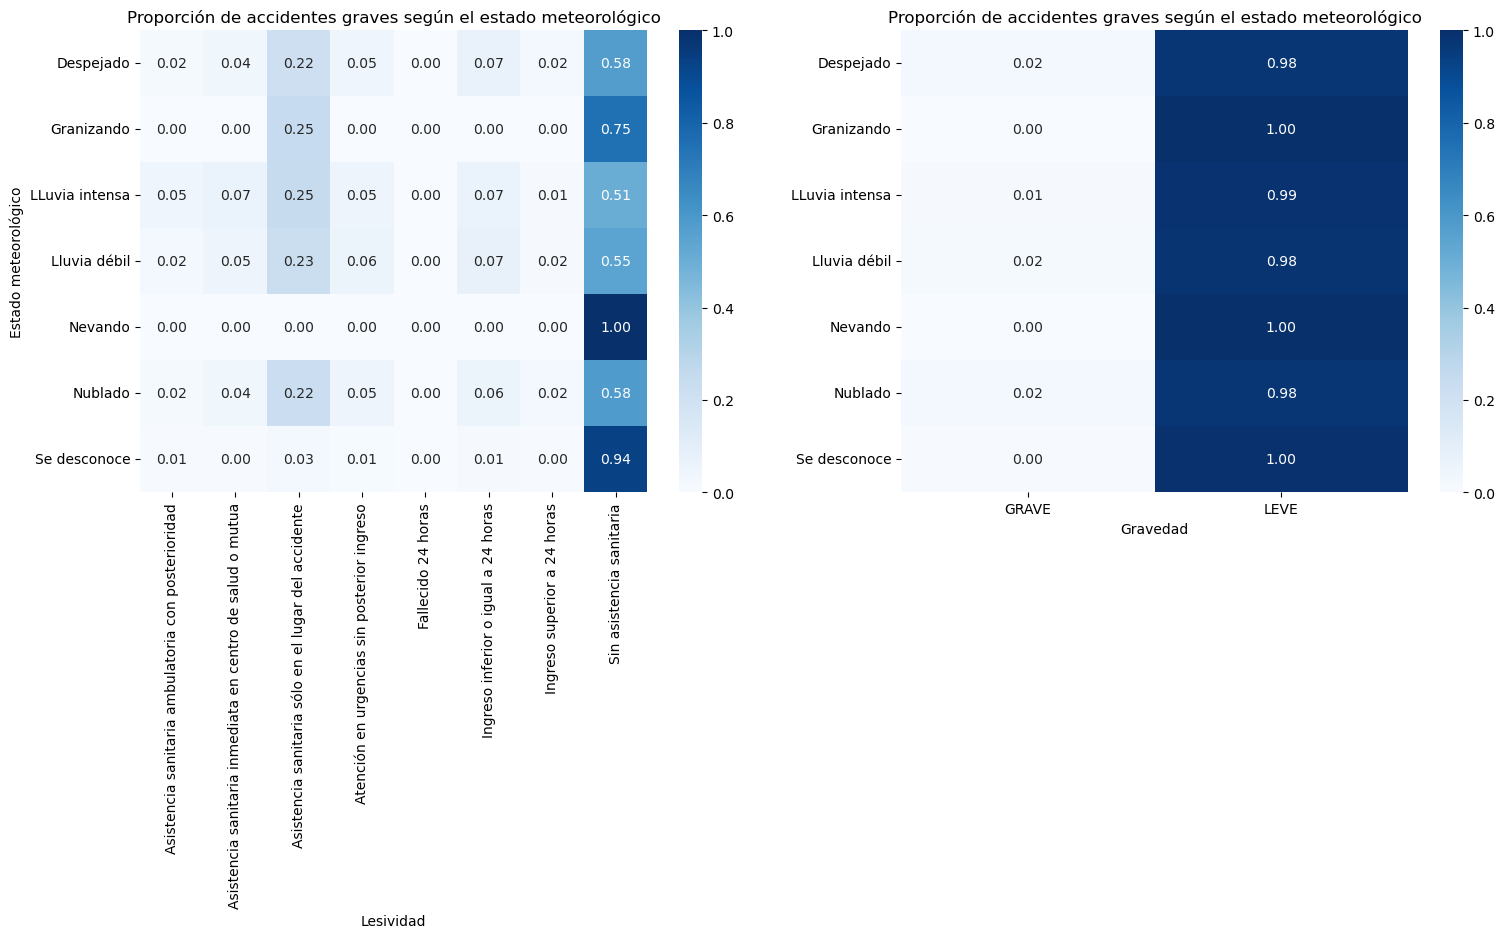

In [170]:
db_filtro = db[db['acc_grave'] != 'Se desconoce']

# Graficas: 1 fila, 2 columnas 
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Tabla1 normalizada por estado meteorológico
tabla1 = pd.crosstab(
    db_filtro["estado_meteorológico"],
    db_filtro["lesividad"],
    normalize="index"
)

# Tabla2 normalizada por estado meteorológico
tabla2 = pd.crosstab(
    db_filtro["estado_meteorológico"],
    db_filtro["acc_grave"],
    normalize="index"
)

sns.heatmap(tabla1, cmap="Blues", annot=True, fmt=".2f", ax=axes[0])
axes[0].set_title("Proporción de accidentes graves según el estado meteorológico")
axes[0].set_ylabel("Estado meteorológico")
axes[0].set_xlabel("Lesividad")

sns.heatmap(tabla2, cmap="Blues", annot=True, fmt=".2f", ax=axes[1])
axes[1].set_title("Proporción de accidentes graves según el estado meteorológico")
axes[1].set_ylabel(" ")
axes[1].set_xlabel("Gravedad")

plt.show()

Se observa que la proporción de accidentes graves se mantiene muy similar en todas las condiciones (en torno al 2–3 %), tanto en días despejados como con lluvia débil o intensa. Esto indica que, en este conjunto de datos, el estado del tiempo no parece modificar de forma relevante la gravedad del accidente, aunque sí influye en el número total de siniestros.

#### ¿En qué franja horaria se producen los accidentes con mayor gravedad?

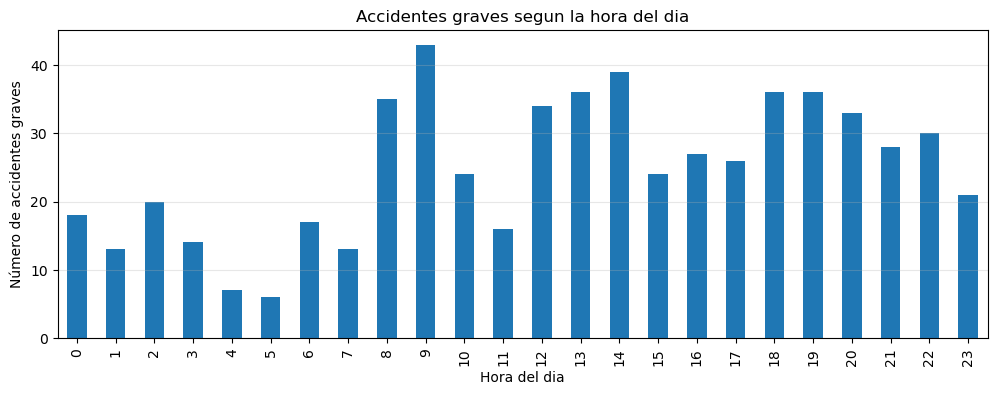

In [172]:
# Graficar 
plt.figure(figsize=(12,4))

db_grave = db[db['acc_grave'] == 'GRAVE']

db_grave['hora_int'].value_counts().sort_index().plot.bar()

plt.xlabel("Hora del dia")
plt.ylabel("Número de accidentes graves")
plt.title("Accidentes graves segun la hora del dia")
plt.grid(axis='y', alpha=0.3)
plt.show()

Los accidentes graves se concentran principalmente en las franjas de mayor movilidad: entre las 08:00–10:00 h, 13:00-16:00 y entre las 18:00–20:00 h. Estas horas coinciden con los desplazamientos laborales de entrada y salida, donde el tráfico es más intenso y, por tanto, aumenta la probabilidad de que los siniestros sean graves. Los dos picos importantes coinciden con el fin de jornadas laborales de tarde y fin de jornada de turnos de mañana, son franjas caracterizadas por un elevado volumen de tráfico, prisas por regresar a casa y mayor cansancio acumulado a lo largo del día laboral.

#### Otros factores de accidentes graves

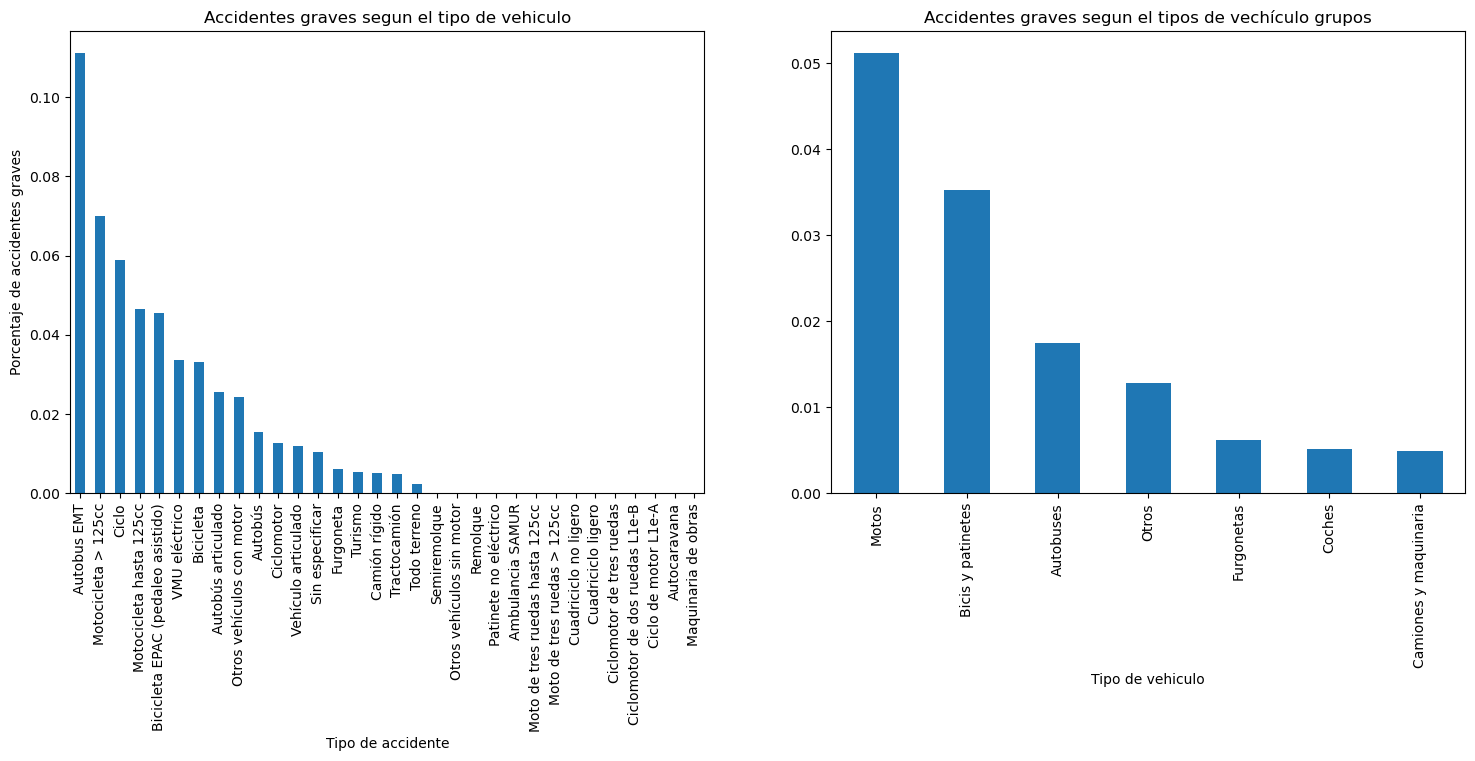

In [174]:
# Graficas: 1 fila, 2 columnas d
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Graficar accidentes graves segun vehiculo en la primera gráfica
tabla_accidente = pd.crosstab(db['tipo_vehiculo'], db['acc_grave'], normalize='index')['GRAVE']
tabla_accidente.sort_values(ascending=False).plot.bar(ax=axes[0])

axes[0].set_xlabel("Tipo de accidente")
axes[0].set_ylabel("Porcentaje de accidentes graves")
axes[0].set_title("Accidentes graves segun el tipo de vehiculo")

# Graficar accidentes graves segun tipo de vehiculo agrupados en la segunda gráfica
tabla_vehiculo = pd.crosstab(db['tipo_vehiculo_grupo'], db['acc_grave'], normalize='index')['GRAVE']
tabla_vehiculo.sort_values(ascending=False).plot.bar(ax=axes[1])

axes[1].set_title("Accidentes graves segun el tipos de vechículo grupos")
axes[1].set_xlabel("Tipo de vehiculo")

plt.show()

En la clasificación original hay tipos de vehículos que aparecen muy pocas veces (como Autobús EMT). Al tener tan pocos casos, su porcentaje de accidentes graves sale artificialmente alto y no refleja realmente el riesgo.

Para hacer un análisis más fiable, se agruparon los vehículos en categorías más generales. Esto evita distorsiones y permite comparar mejor qué tipos de vehículos tienen más gravedad.
Después de agrupar, se ve claramente que las motos son el tipo de vehículo con mayor proporción de accidentes graves.

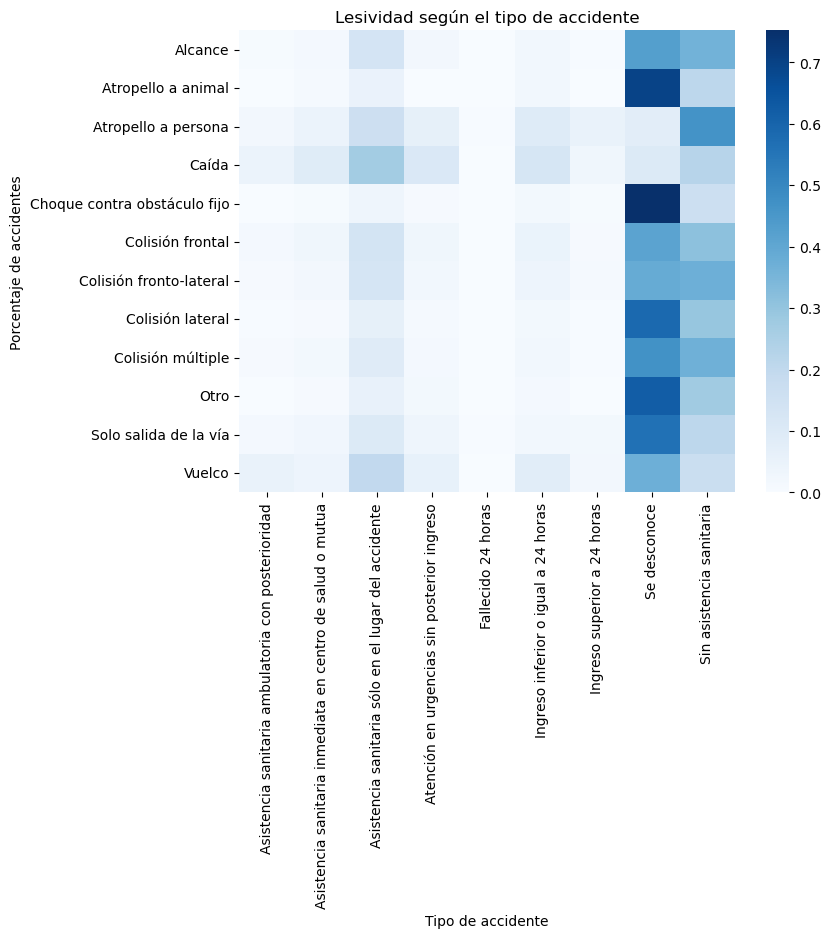

In [176]:
# Graficar accidentes graves segun vehiculo en la primera gráfica
tabla = pd.crosstab(db["tipo_accidente"], db["lesividad"], normalize="index")
sns.heatmap(tabla, cmap="Blues", annot=False)

plt.xlabel("Tipo de accidente")
plt.ylabel("Porcentaje de accidentes")
plt.title("Lesividad según el tipo de accidente")

plt.show()

El mapa de calor tiene demasiada información y se hace difícil de leer.
Por eso vamos a usar `acc_grave`, que resume la gravedad en dos niveles, y así podremos ver la relación de manera mucho más clara.

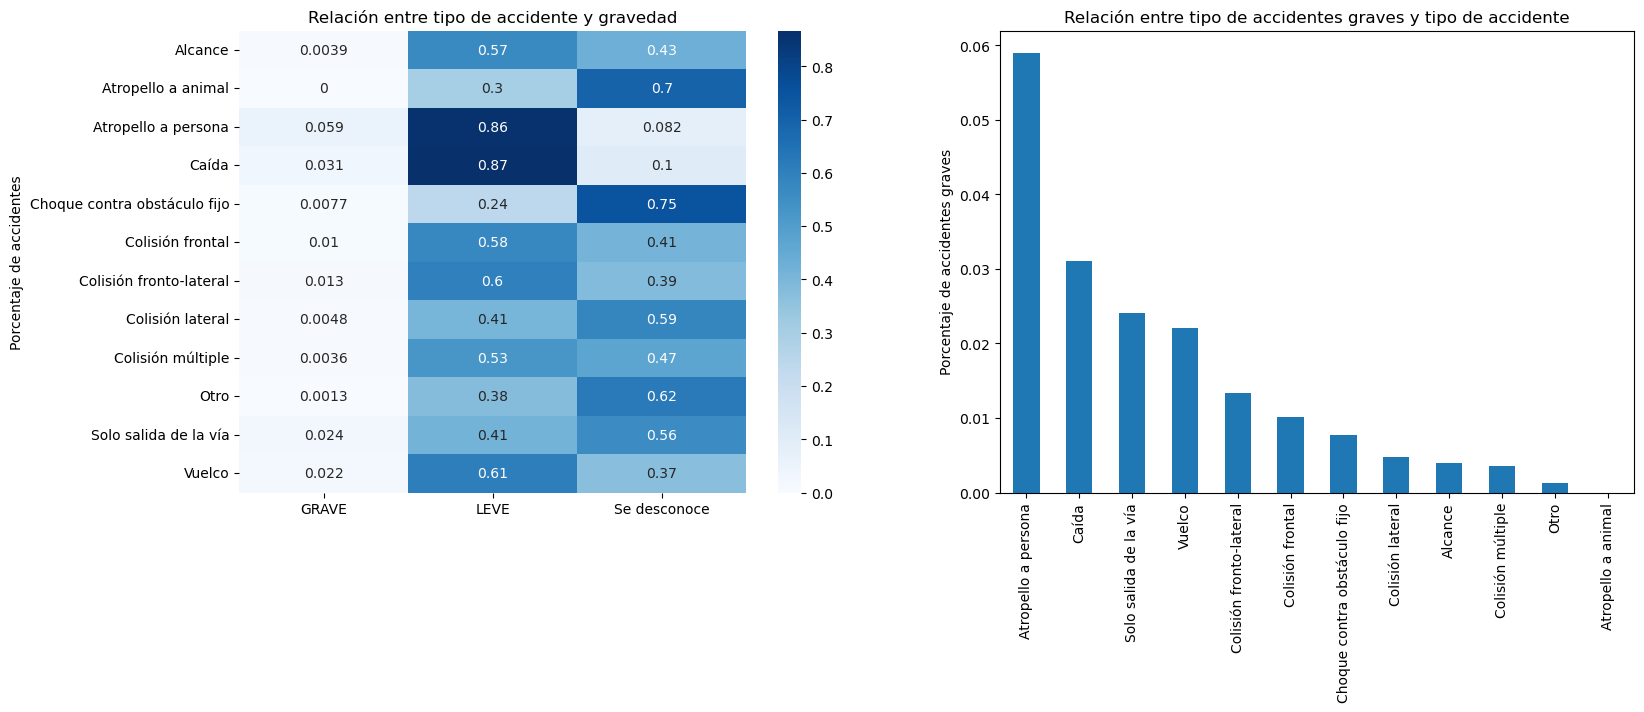

In [178]:
# Graficas: 1 fila, 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Grafica mapa de calor de los accidentes graves según tipo de accidentes
tabla = pd.crosstab(db["tipo_accidente"], db["acc_grave"], normalize="index")
sns.heatmap(tabla, cmap="Blues", annot=True, ax=axes[0])

axes[0].set_xlabel("")
axes[0].set_ylabel("Porcentaje de accidentes")
axes[0].set_title("Relación entre tipo de accidente y gravedad")

# Grafica en barra de accidentes graves según tipo de accidentes
tabla_accidente = pd.crosstab(db['tipo_accidente'], db['acc_grave'], normalize='index')['GRAVE']
tabla_accidente.sort_values(ascending=False).plot.bar(ax=axes[1])

axes[1].set_title("Relación entre tipo de accidentes graves y tipo de accidente")
axes[1].set_xlabel("")
axes[1].set_ylabel("Porcentaje de accidentes graves")

plt.show()

En las gráficas se observa que los accidentes con mayor proporción de lesiones graves son los `atropellos a personas`, seguidos por los accidentes por `caídas`, `salida de la vía` y los `vuelcos`.

Estos resultados son coherentes, ya que los peatones son el grupo más vulnerable: no cuentan con ningún tipo de protección y cualquier impacto puede producir lesiones graves. En el caso de las caídas, los ocupantes del vehículo también están más expuestos, lo que incrementa el riesgo de lesiones importantes. De forma similar, los accidentes por salida de vía o vuelco suelen ser accidentes bruscos y de alta energía, lo que tiende a generar un nivel de lesividad más alto.

Text(0.5, 1.0, 'Accidentes graves segun el tipo de persona')

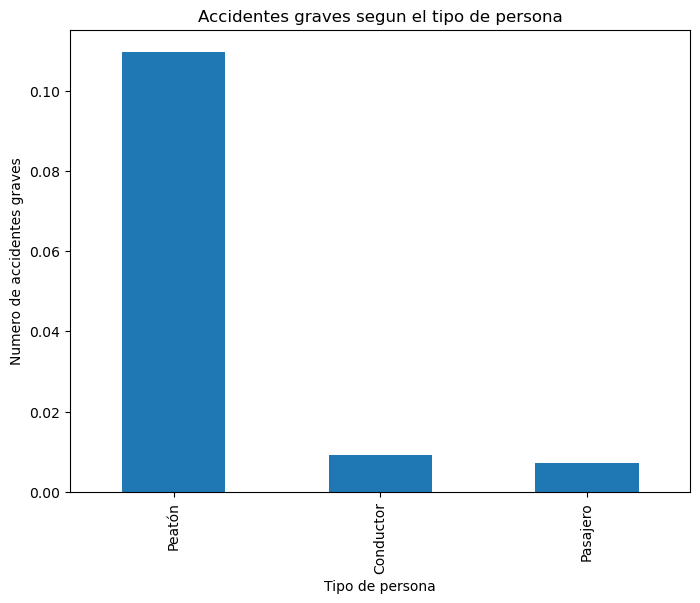

In [180]:
# Graficar accidentes graves según tipo de persona
tabla_pers = pd.crosstab(db['tipo_persona'], db['acc_grave'], normalize='index')['GRAVE']
tabla_pers.sort_values(ascending=False).plot.bar()

plt.xlabel("Tipo de persona")
plt.ylabel("Numero de accidentes graves")
plt.title("Accidentes graves segun el tipo de persona")


Text(0.5, 1.0, 'Probavilidad de que un accidentes sea grave según sexo')

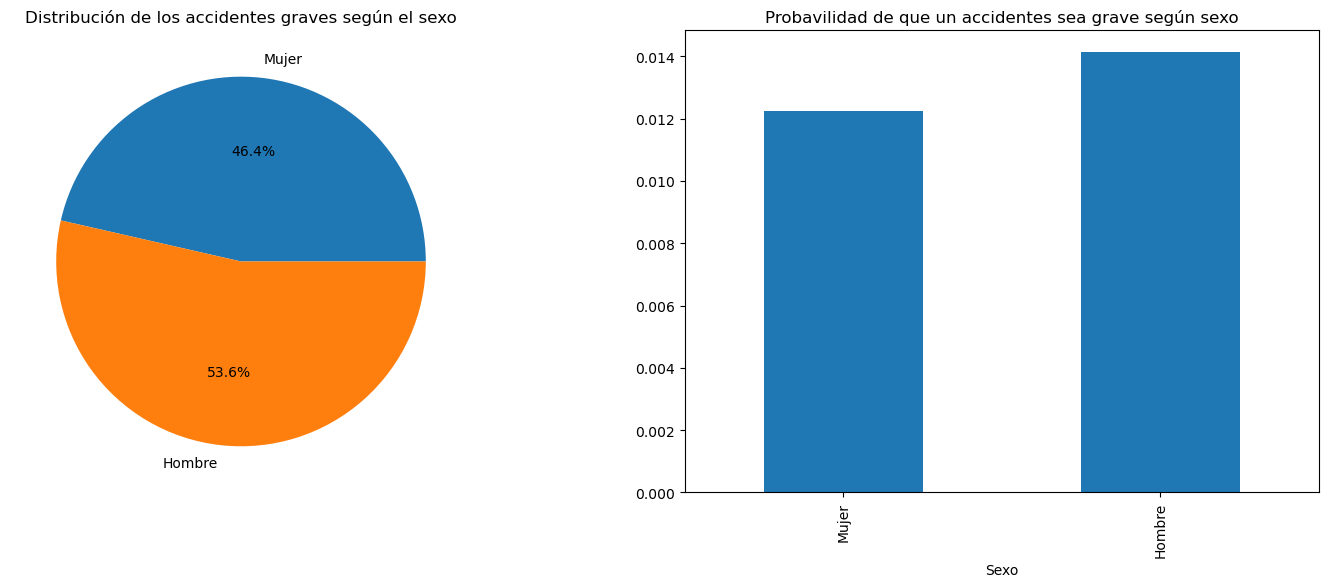

In [181]:
# Graficas: 1 fila, 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Hacer una tabla de contingencia para ver la relación entre las columnas 'sexo' y 'acc_grave'
tabla_sexo = pd.crosstab(db['sexo'], db['acc_grave'], normalize='index')['GRAVE']
tabla_sexo = tabla_sexo.drop('Desconocido')

# Graficar accidentes graves segun sexo
tabla_sexo.sort_values().plot.pie(autopct='%1.1f%%', ax=axes[0])

axes[0].set_xlabel("")
axes[0].set_ylabel("")
axes[0].set_title("Distribución de los accidentes graves según el sexo")

# Graficar accidentes graves segun sexo
tabla_sexo.sort_values().plot.bar(ax=axes[1])

axes[1].set_xlabel("Sexo")
axes[1].set_ylabel("")
axes[1].set_title("Probavilidad de que un accidentes sea grave según sexo")



En la primera gráfica mostramos cuántos accidentes graves corresponden a cada sexo. A simple vista parece que los hombres sufren más accidentes graves, pero este resultado está influido porque, en el conjunto de datos, hay muchos más accidentes protagonizados por hombres que por mujeres. Por ello, esta gráfica no refleja la probabilidad real, solo el volumen total.

Para obtener una comparación justa, utilizamos la segunda gráfica, que representa la probabilidad de que un accidente sea grave dentro de cada sexo. Aquí sí vemos la diferencia real: las mujeres presentan una probabilidad ligeramente superior al 0,12%, mientras que en los hombres es de aproximadamente el 0,14%.

La diferencia es pequeña, pero indica que, proporcionalmente los hombres tienen una probabilidad algo mayor de sufrir un accidente grave.

Text(0.5, 1.0, 'Accidentes graves segun el distrito')

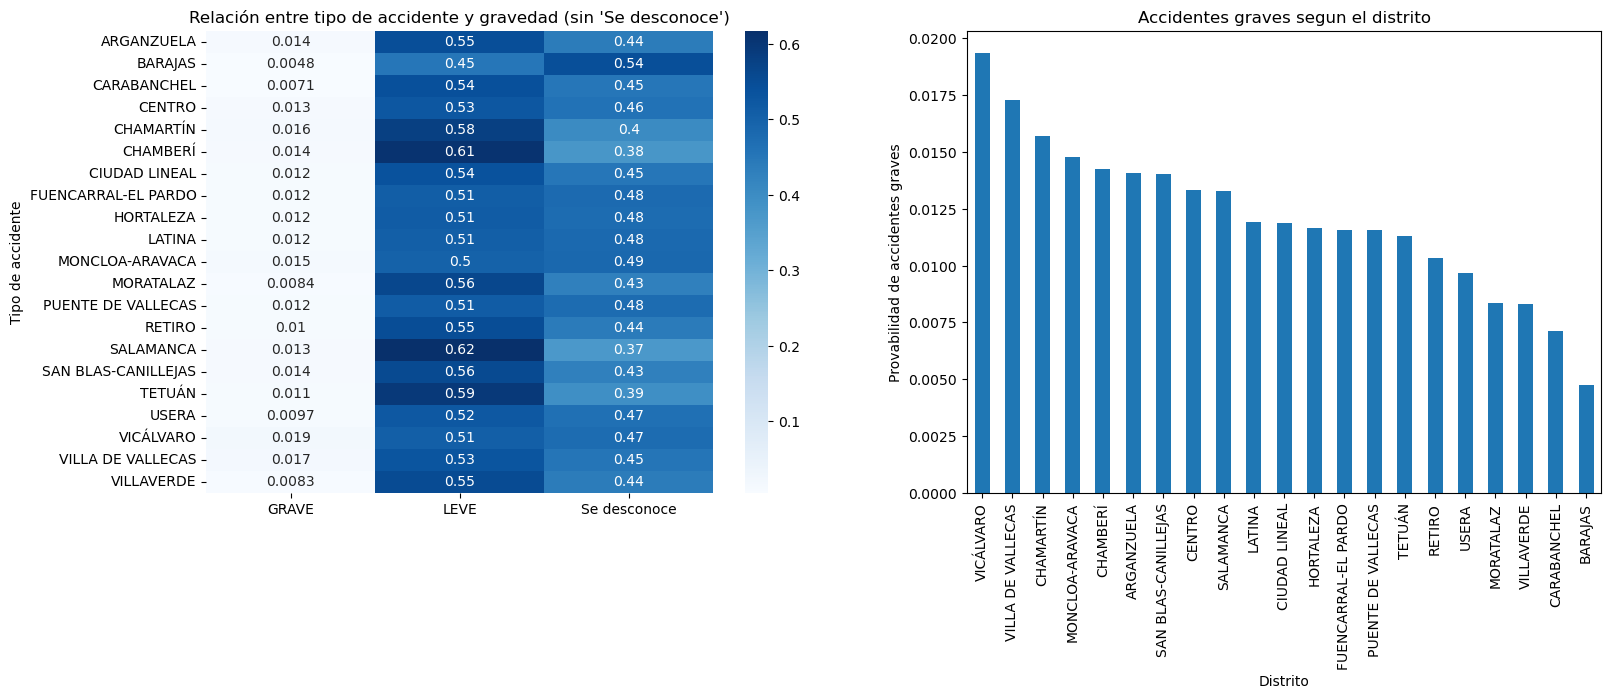

In [183]:
# Graficas: 1 fila, 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Graficar accidentes graves segun distrito 
tabla = pd.crosstab(db["distrito"], db["acc_grave"], normalize="index")

sns.heatmap(tabla, cmap="Blues", annot=True, ax=axes[0])
axes[0].set_title("Relación entre tipo de accidente y gravedad (sin 'Se desconoce')")
axes[0].set_xlabel("")
axes[0].set_ylabel("Tipo de accidente")

# Graficar accidentes graves distrito
tabla_pers = pd.crosstab(db['distrito'], db['acc_grave'], normalize='index')['GRAVE']
tabla_pers.sort_values(ascending=False).plot.bar(ax=axes[1])

axes[1].set_xlabel("Distrito")
axes[1].set_ylabel("Provabilidad de accidentes graves")
axes[1].set_title("Accidentes graves segun el distrito")

Los distritos con mayor proporción de accidentes graves, como Vicálvaro y Villa de Vallecas, no coinciden necesariamente con los distritos con mayor número total de siniestros. Este patrón podría estar relacionado con la presencia de vías de alta capacidad y una menor congestión del tráfico, lo que favorece velocidades de circulación más elevadas y, en consecuencia, una mayor severidad de los accidentes cuando estos se producen.

Se trata de distritos con una estructura urbana menos densa que las zonas centrales, lo que refuerza esta interpretación.

### Análisis de sesgo y validación de datos
Vamos emprezar por analizar la presencia de valores “Se desconoce”, esto no supone necesariamente un sesgo. Sin embargo, si estos valores se concentran en determinados tipos de accidente, grupos de edad o distritos, puede indicar un sesgo en la recogida de la información, ya que la ausencia de datos no sería aleatoria.

In [186]:
db['acc_grave'].value_counts()

acc_grave
LEVE            26744
Se desconoce    21828
GRAVE             596
Name: count, dtype: int64

<Axes: xlabel='distrito'>

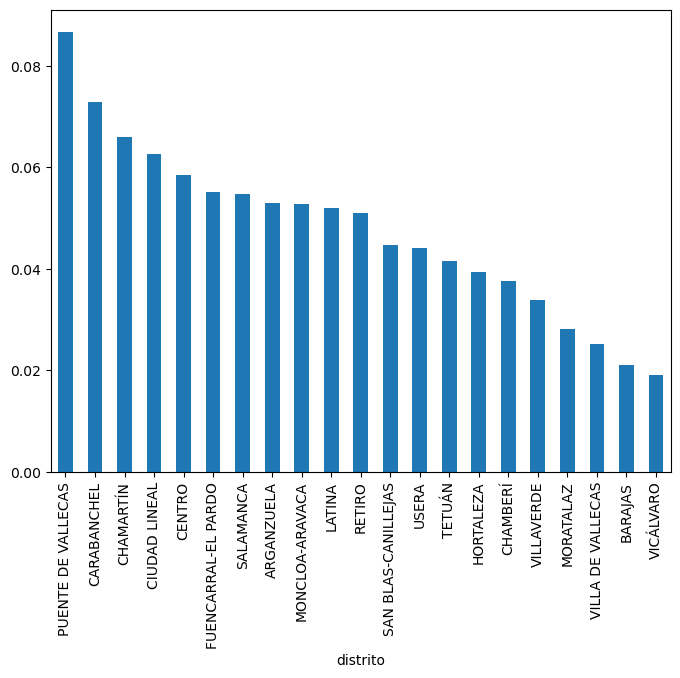

In [187]:
pd.crosstab(
    db['acc_grave'],
    db['distrito'],
    normalize='index'
).loc['Se desconoce'].sort_values(ascending=False).plot.bar()


Se analizó la distribución de los accidentes con gravedad “Se desconoce” por distrito para detectar posibles sesgos.

Los resultados muestran que estos casos se distribuyen de forma proporcional entre los distritos con mayor número de accidentes totales, sin concentrarse de manera anómala en ningún distrito concreto.

Por tanto, no se identifican indicios de sesgo sistemático asociados a la variable distrito en los registros con gravedad desconocida.

<Axes: xlabel='hora_int'>

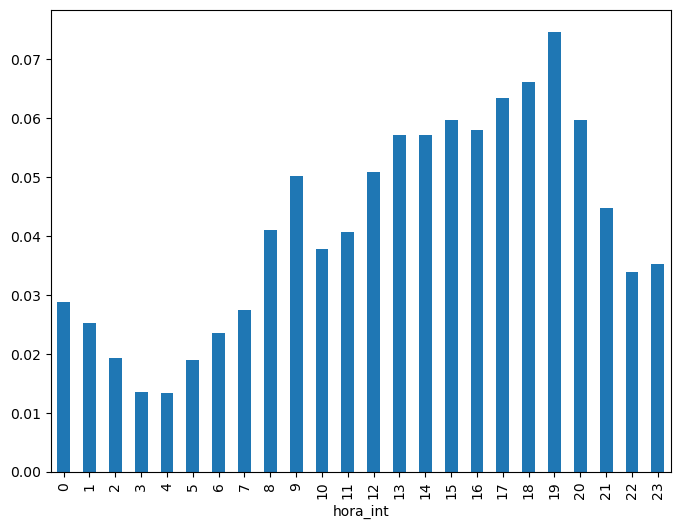

In [189]:
pd.crosstab(
    db['acc_grave'],
    db['hora_int'],
    normalize='index'
).loc['Se desconoce'].plot.bar()


Al analizar la distribución de los valores “Se desconoce” por hora del día, se observa un patrón coherente con la distribución general de los accidentes. Las franjas horarias con mayor volumen de accidentes son también aquellas donde aparece un mayor número de registros “Se desconoce”.

Este comportamiento indica que los valores “Se desconoce” no se concentran de forma anómala en determinadas horas, sino que siguen la intensidad general del tráfico y de los accidentes. Por tanto, no se identifican indicios de sesgo asociados a la variable temporal, y no se considera necesario continuar analizando esta categoría en más variables.

In [191]:
# Lista de accidentes en los que aparece al menos una bicicleta
acc_bici = db.loc[db['tipo_vehiculo'] == 'Bicicleta', 'num_expediente'].unique()

# Lista de accidentes en los que aparece al menos un peatón
acc_peaton = db.loc[db['tipo_persona'] == 'Peatón', 'num_expediente'].unique()

# Accidentes donde coinciden bicicleta y peatón
acc_bici_peaton = set(acc_bici) & set(acc_peaton)

# Crear un dataframe
db_peaton_bici = db[db['num_expediente'].isin(acc_bici_peaton)]

# Contar implicados por accidente y filtrar por >2
db_peaton_bici['num_expediente'].value_counts()[lambda x: x>2]

num_expediente
2024S023052    6
2024S002805    5
2024S025351    3
2024S005354    3
2024S008385    3
2024S033181    3
2024S021493    3
2024S025863    3
Name: count, dtype: int64

In [192]:
db[db['num_expediente'] == '2024S023052']['tipo_persona']

28264    Conductor
28265    Conductor
28266    Conductor
28267     Pasajero
28268     Pasajero
28269       Peatón
Name: tipo_persona, dtype: category
Categories (3, object): ['Conductor', 'Pasajero', 'Peatón']

In [193]:
db[db['num_expediente'] == '2024S023052']['tipo_vehiculo']

28264    Bicicleta
28265      Turismo
28266      Turismo
28267      Turismo
28268      Turismo
28269      Turismo
Name: tipo_vehiculo, dtype: category
Categories (32, object): ['Ambulancia SAMUR', 'Autobus EMT', 'Autobús', 'Autobús articulado', ..., 'Tractocamión', 'Turismo', 'VMU eléctrico', 'Vehículo articulado']

In [194]:
db[db['num_expediente'] == '2024S002805']['tipo_persona'] 

3251    Conductor
3252     Pasajero
3253       Peatón
3254       Peatón
3255    Conductor
Name: tipo_persona, dtype: category
Categories (3, object): ['Conductor', 'Pasajero', 'Peatón']

In [195]:
db[db['num_expediente'] == '2024S002805']['tipo_vehiculo']

3251    Bicicleta
3252    Bicicleta
3253    Bicicleta
3254    Bicicleta
3255    Furgoneta
Name: tipo_vehiculo, dtype: category
Categories (32, object): ['Ambulancia SAMUR', 'Autobus EMT', 'Autobús', 'Autobús articulado', ..., 'Tractocamión', 'Turismo', 'VMU eléctrico', 'Vehículo articulado']

No hay ningún caso que haya más de dos implicados, por tanto tiene lógica y podriamos considerar que no existen sesgos en este caso

In [197]:
tab = pd.crosstab(db['tipo_accidente'], db['lesividad'], normalize='index')

tab.drop(columns=['Se desconoce'], errors='ignore')

lesividad,Asistencia sanitaria ambulatoria con posterioridad,Asistencia sanitaria inmediata en centro de salud o mutua,Asistencia sanitaria sólo en el lugar del accidente,Atención en urgencias sin posterior ingreso,Fallecido 24 horas,Ingreso inferior o igual a 24 horas,Ingreso superior a 24 horas,Sin asistencia sanitaria
tipo_accidente,,,,,,,,
Alcance,0.008130,0.016675,0.133234,0.021570,0.000332,0.025801,0.003567,0.362701
Atropello a animal,0.000000,0.013158,0.052632,0.000000,0.000000,0.026316,0.000000,0.210526
Atropello a persona,0.021431,0.046818,0.163205,0.067260,0.005275,0.096274,0.053742,0.463897
Caída,0.045676,0.090228,0.272183,0.108948,0.000749,0.124672,0.030326,0.225384
Choque contra obstáculo fijo,0.002641,0.007733,0.034892,0.010562,0.000189,0.019049,0.007544,0.165786
Colisión frontal,0.017463,0.032169,0.136949,0.030331,0.000919,0.047794,0.009191,0.312500
Colisión fronto-lateral,0.009688,0.022328,0.132077,0.023993,0.000227,0.040039,0.013170,0.372464
Colisión lateral,0.004631,0.011391,0.067343,0.013018,0.000000,0.018901,0.004757,0.294154
Colisión múltiple,0.009120,0.018636,0.092784,0.015067,0.000000,0.023791,0.003569,0.367962


El análisis de la relación entre el tipo de accidente y la lesividad muestra patrones coherentes con la naturaleza de los siniestros. Los atropellos a personas, las caídas y los vuelcos presentan una mayor proporción de lesiones graves, mientras que los alcances y colisiones simples concentran mayoritariamente casos leves o sin asistencia sanitaria.

No se observan combinaciones incoherentes entre tipo de accidente y gravedad que sugieran errores sistemáticos o sesgos en el registro de la lesividad.

**Conclusion de sesgos**

Tras el análisis realizado, no se identifican sesgos significativos en el dataset.

Las diferencias observadas en la distribución de accidentes por distrito, franja horaria o edad responden a factores estructurales y de exposición al riesgo.
La categoría “Se desconoce” no presenta concentraciones anómalas y mantiene una distribución coherente con el total de registros.
Asimismo, la relación entre tipo de accidente y lesividad es consistente con la naturaleza de los siniestros, sin evidencias de errores sistemáticos o incoherencias en el registro de los datos.

### Identificación de outliners

La variable `hora_int` fue derivada directamente de la columna fecha_hora mediante funciones de tipo datetime.
Al tratarse de una transformación controlada, los valores quedan restringidos al rango válido [0–23], por lo que no es posible la presencia de valores fuera de rango en esta variable.

In [201]:
# Comprobar horas extremas
horas = db['fecha_hora'].dt.hour
horas.min(), horas.max()

(0, 23)

In [202]:
# Comprobar fechas extremas
db['fecha_hora'].min(), db['fecha_hora'].max()

(Timestamp('2024-01-01 01:20:00'), Timestamp('2024-12-31 23:15:00'))

No existe ninguna hora con un valor imposible (hora 27). Por tanto, no existe outliers en las horas.

Para ver si existen outliers en las coordenadas, buscamos y sabemos que Madrid se encuentra principalmente en la Zona UTM 30T (Husos 30 y 31), usando el sistema de referencia ETRS89, con coordenadas UTM que varían aproximadamente entre **410.000 y 440.000** m E (Este) y **4.480.000 y 4.500.000** m N (Norte), por tanto vamos a analizar si los valores estan dentro de estas coordenadas.

In [204]:
db[['coordenada_x_utm', 'coordenada_y_utm']].describe()

,coordenada_x_utm,coordenada_y_utm
count,49168.000000,4.916800e+04
mean,442072.609238,4.474662e+06
std,3475.886392,3.962668e+03
min,429177.000000,4.463657e+06
25%,439892.000000,4.471611e+06
50%,441749.000000,4.474652e+06
75%,443997.000000,4.477470e+06
max,454754.000000,4.492208e+06


Aunque existen valores extremos en las coordenadas UTM, estos se encuentran dentro de los rangos esperables para el área geográfica de Madrid, por lo que no se consideran valores atípicos sino parte de la variabilidad espacial del dataset.

### Análisis geográfico

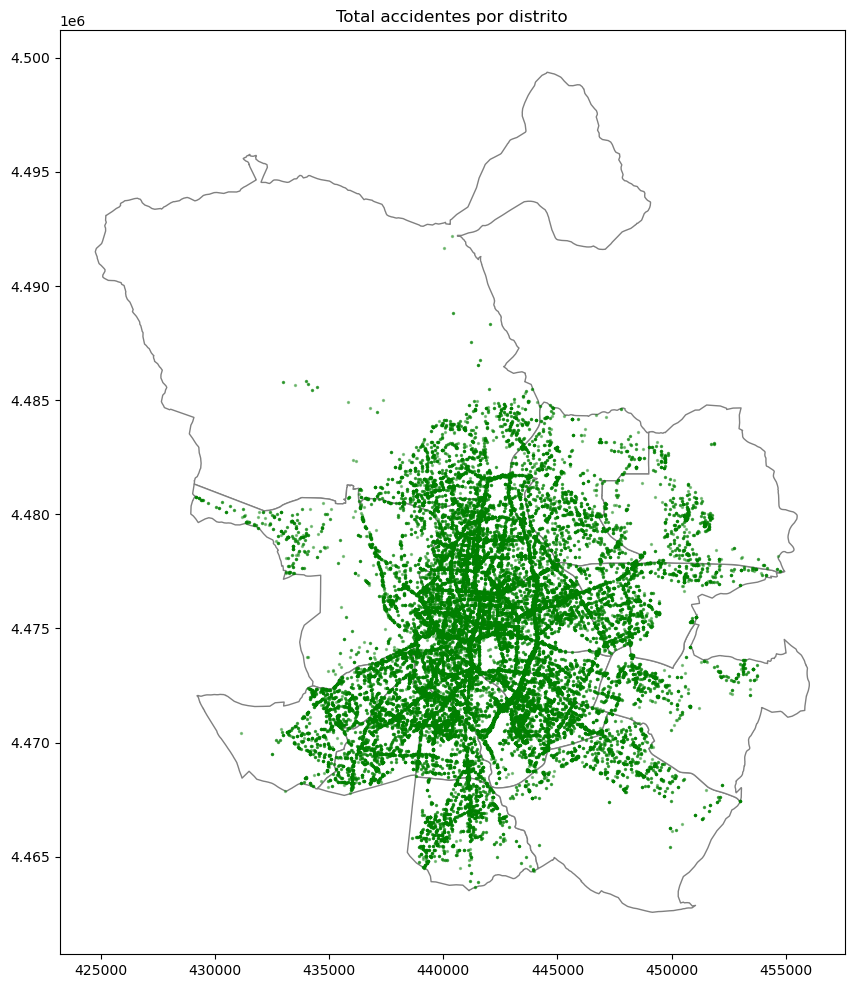

In [207]:
# Cargar distritos (Madrid usa ETRS89 / UTM zone 30N → EPSG:25830)
districts = gpd.read_file("distritos/DISTRITOS.shp")

dbgeo = gpd.GeoDataFrame(
    db, 
    geometry=gpd.points_from_xy(db["coordenada_x_utm"], db["coordenada_y_utm"]), 
    crs="EPSG:25830"
)

fig, ax = plt.subplots(figsize=(12,12))

districts.plot(ax=ax, color="white", edgecolor="gray")

# Puntos de accidentes 'grave', 'leve' y 'se desconoce'
dbgeo.plot(ax=ax, markersize=2, alpha=0.4, color="green")


plt.title("Total accidentes por distrito")
plt.show()


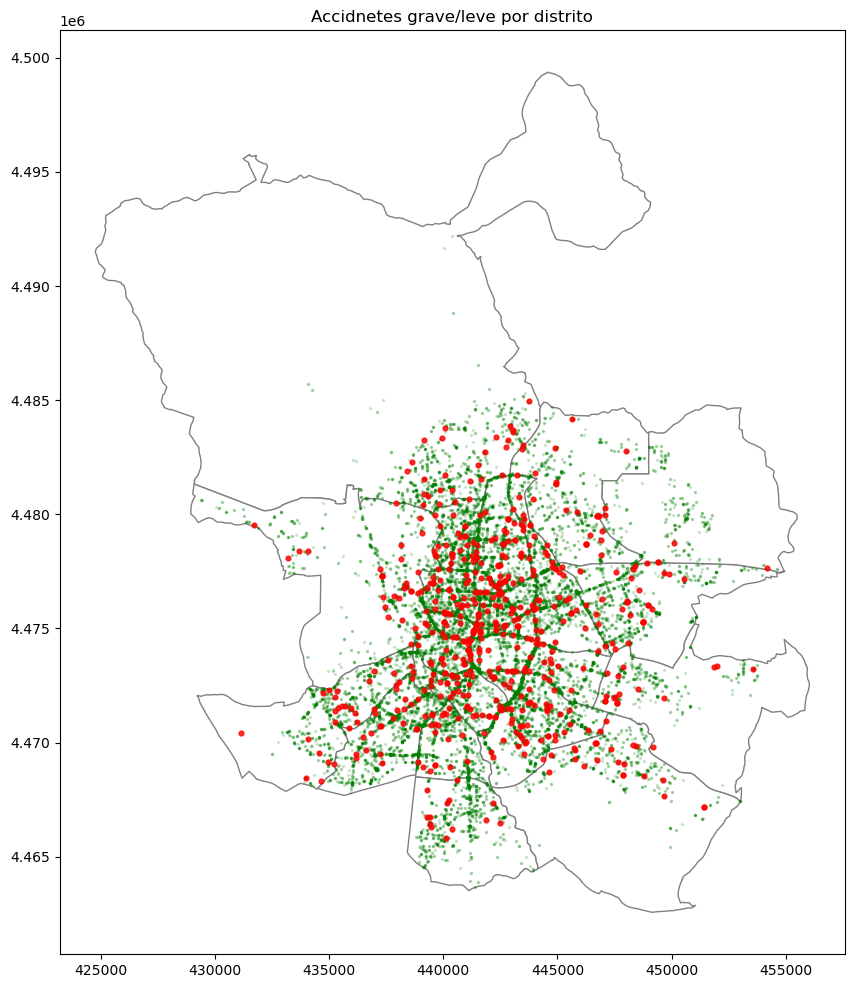

In [208]:
# Cargar distritos (Madrid usa ETRS89 / UTM zone 30N → EPSG:25830)
districts = gpd.read_file("distritos/DISTRITOS.shp")

dbgeo = gpd.GeoDataFrame(db, geometry=gpd.points_from_xy(db["coordenada_x_utm"], db["coordenada_y_utm"]), crs="EPSG:25830")
fig, ax = plt.subplots(figsize=(12,12))

districts.plot(ax=ax, color="white", edgecolor="gray")

# Puntos de accidentes LEVE 
dbgeo[dbgeo["acc_grave"]=="LEVE"].plot(ax=ax, markersize=2, alpha=0.15, color="green")

# Puntos de accidentes GRAVE
dbgeo[dbgeo["acc_grave"]=="GRAVE"].plot(ax=ax, markersize=12, alpha=0.8, color="red", marker="o")

plt.title("Accidnetes grave/leve por distrito")
plt.show()


La figura muestra la distribución espacial de los accidentes de tráfico en el municipio de Madrid. Se observa una clara concentración de siniestros en las zonas centrales de la ciudad, así como a lo largo de los principales ejes viarios y grandes avenidas. Este patrón es coherente con áreas de mayor densidad urbana, mayor intensidad de tráfico y presencia de vías de alta capacidad.

En contraste, las zonas periféricas presentan una menor densidad de accidentes, lo que puede explicarse por una menor concentración de actividad urbana y un menor volumen de desplazamientos diarios. La distribución espacial observada no sugiere un sesgo en la recogida de los datos, sino que refleja diferencias estructurales en el uso del espacio urbano y en la exposición al tráfico.

La distribución espacial de los accidentes graves (puntos rojos) no muestra la presencia de zonas calientes claramente definidas, sino una dispersión relativamente homogénea a lo largo del área urbana. No obstante, se observa una mayor concentración en el centro de la ciudad y en los principales ejes viarios, lo que resulta coherente con áreas de mayor intensidad de tráfico y movilidad.

## Conclusiones del EDA
Pregunta negocio: 

**'¿En qué franja horaria se producen los accidentes con mayor gravedad y qué condiciones pueden influir en ello?'**

Tras un análisis exploratorio de los datos, se observa que los accidentes con mayor gravedad se concentran principalmente en las franjas horarias de **8:00 a 10:00**, **13:00 a 16:00** y **18:00 a 20:00**, coincidiendo con las horas punta de mayor movilidad urbana, como la entrada y salida laboral y los desplazamientos habituales del mediodía.

En cuanto a las condiciones asociadas a una mayor gravedad, destacan especialmente el **rango de edad**, el **tipo de persona implicada** y el **tipo de accidente**. Los grupos de **mayores de 75 años**, los **peatones** y los accidentes por **atropello a persona** y **caída** presentan una mayor proporción de accidentes graves, lo que refleja una mayor vulnerabilidad frente a impactos. Asimismo, las **motocicletas** destacan como el tipo de vehículo con mayor proporción de accidentes graves.

A nivel territorial, algunos distritos con **vías de alta capacidad y mayor velocidad**, como **Vicálvaro** y **Villa de Vallecas**, muestran una mayor proporción de accidentes graves, lo que sugiere que la configuración viaria y la velocidad del tráfico pueden influir en la gravedad de los siniestros.

Por el contrario, variables como el estado meteorológico y los resultados positivos en alcohol o drogas no muestran una relación clara con una mayor gravedad del accidente en términos relativos, una vez normalizados los datos.

En conjunto, los resultados indican que la gravedad de los accidentes está más relacionada con **factores estructurales, de exposición y vulnerabilidad** que con condiciones puntuales como el clima o el consumo de sustancias.



# Uso del Modelo de Regresión Logística

Inicialmente, se probó un enfoque simplificado de regresión logística con codificación básica de variables categóricas mediante **LavelEncoder**. Sin embargo, debido al fuerte desbalance de la variable objetivo, este modelo no resultó adecuado, ya que no detectaba correctamente los casos positivos.
Daba un `accuracy` de 0.9708 y en la clase 1 (positivo alcohol) daba los resultados de `precision` = 0.00, `recall` = 0.00, `F1-score` = 0.00, es decir, no había muestras predichas de la clase positiva. Este modelo aprendió que para minimizar el error global, era mejor predecir siempre NO, y matemáticamente tenía razón, dado el desbalance. Un modelo que decía "nadie da positivo" ya acertaba el 97%. Ese modelo **no aprendió a detectar positivos.**

Posteriormente, se ha implementado un modelo más robusto utilizando Pipeline que integra un preprocesador de las variables categóricas mediante **OneHotEncoder** junto con la regresión logística. Este enfoque permite un tratamiento más apropiado de las variables categóricas.

In [212]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# Importar la clase de AlcoholicLogisticModel
from models import AlcoholLogisticModel

In [213]:
# Nota: el fichero de datos no se incluye en la entrega (se genera en el EDA)
db = pd.read_pickle("db_limpio.pkl")

In [214]:
# Definir la variable objetivo (y)
y = db['positiva_alcohol'].copy(deep=True)

In [215]:
# Definir las variables predictoras (X)
X = db[['rango_edad','tipo_accidente','estado_meteorológico','tipo_vehiculo_grupo','tipo_persona','sexo','hora_int','dia_sem']].copy(deep=True)

En un escenario real, las variables `acc_grave`, `lesividad` y `cod_lesividad` no estarían disponibles en el momento de la predicción. Por este motivo, se excluyen del conjunto de variables predictoras con el fin de evitar **data leakage**. 

In [217]:
# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [218]:
# Definir qué columnas son categóricas y numéricas
categorical_f = ["rango_edad", "tipo_accidente", "estado_meteorológico", "tipo_vehiculo_grupo", "tipo_persona", "sexo"]
numeric_f = ["hora_int", "dia_sem"]

In [219]:
# Entrenar el modelo
model = AlcoholLogisticModel(categorical_f=categorical_f, numeric_f=numeric_f, random_state=42, max_iter=1000, class_weight="balanced")

model.fit(X_train, y_train)

# Evaluación

In [221]:
metrics = model.evaluate(X_test, y_test)
metrics

{'accuracy': 0.7286963595688428,
 'precision': 0.0767863490934945,
 'recall': 0.7526132404181185,
 'f1': 0.1393548387096774,
 'confusion_matrix': array([[6950, 2597],
        [  71,  216]], dtype=int64)}

*Nota: Se ha utilizado una única partición train/test para evaluar el modelo, lo cual es adecuado en un contexto exploratorio y permite una evaluación rápida del rendimiento. No obstante, este enfoque puede depender de cómo se realiza la partición de los datos. Como mejora futura, se podría aplicar validación cruzada (k-fold cross validation) para obtener una estimación más robusta del rendimiento del modelo y reducir la variabilidad asociada a una única división.*

`Accuracy`:  El modelo acierta aproximadamente el 73% de los casos. Aunque este valor es inferior al obtenido en un modelo previo, resulta más representativo, ya que el modelo actual sí está capturando la clase minoritaria (positivos en alcohol).

`Precision`:  De todos los casos que el modelo predice como positivos, solo el 7.7% lo son realmente. Este valor es bajo, lo cual es esperable en datasets desbalanceados donde la clase positiva es minoritaria. El modelo tiende a generar falsos positivos para aumentar la detección de casos reales.

`Recall`: El modelo detecta aproximadamente el 75% de los verdaderos positivos. Dado que el objetivo es no dejar pasar casos de alcohol, esta es la métrica más relevante y su valor es satisfactorio.

`F1`: Representa el equilibrio entre precisión y recall. Su valor es bajo, pero coherente con una alta sensibilidad (recall) y baja precisión en un contexto de fuerte desbalanceo.

`Confusion_matrix`: El modelo detecta 216 positivos correctamente, pero pierde 71. Además, genera un número elevado de falsos positivos (2597). Esto indica que el modelo prioriza la detección de positivos, sacrificando precisión.

In [223]:
# Ver predicciones
y_pred = model.predict(X_test)
y_pred

array([1., 1., 0., ..., 0., 0., 0.])

In [224]:
# Ver probabilidades y casos limite
proba = model.predict_proba(X_test)[:, 1] # todas las filas de la clase positiva
proba[:10]

array([6.66496055e-01, 6.02904003e-01, 4.43759153e-01, 7.82320746e-02,
       1.23619605e-01, 5.82075238e-04, 5.75199283e-01, 1.40537410e-01,
       3.55821882e-02, 4.83019511e-01])

El método predict_proba devuelve la probabilidad estimada de pertenencia a la clase positiva para cada observación, lo que permite analizar la confianza del modelo y detectar casos cercanos al umbral de decisión.

- 0.66, 0.62 y 0.58 -> alta probabilidad de positivo en alcohol.
- 0.48 y 0.44 -> casos cercanos al umbral de decisión, considerados casos límite.
- 0.35 -> probabilidad media, con incertidumbre relevante.
- 0.14, 0.12 y 0.07 -> baja o muy baja probabilidad de positivo.
  
Se observa que algunos se sitúan próximos al umbral de decisión (0.5), lo que refleja situaciones de mayor incertidumbre en la predicción. No obstante, la mayoría de los ejemplos presentan probabilidades alejadas del umbral, lo que indica decisiones relativamente claras por parte del modelo.

Estos resultados son hechos con el umbral 0.5, pero este umbral puede ajustarse de forma manual en función del objetivo de análisis, permitiendo priorizar la detección de positivos o la reducción de falsos positivos según lo que interese más.

# Umbral

In [227]:
proba = model.predict_proba(X_test)[:, 1]

# Ver y comprobar diferentes umbrales
for threshold in [0.5, 0.4, 0.3, 0.2]:
    y_pred = (proba >= threshold).astype(int)
    print(f"\nUmbral: {threshold}")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred, zero_division=0))



Umbral: 0.5
[[6950 2597]
 [  71  216]]
              precision    recall  f1-score   support

         0.0       0.99      0.73      0.84      9547
         1.0       0.08      0.75      0.14       287

    accuracy                           0.73      9834
   macro avg       0.53      0.74      0.49      9834
weighted avg       0.96      0.73      0.82      9834


Umbral: 0.4
[[5656 3891]
 [  45  242]]
              precision    recall  f1-score   support

         0.0       0.99      0.59      0.74      9547
         1.0       0.06      0.84      0.11       287

    accuracy                           0.60      9834
   macro avg       0.53      0.72      0.43      9834
weighted avg       0.96      0.60      0.72      9834


Umbral: 0.3
[[4401 5146]
 [  21  266]]
              precision    recall  f1-score   support

         0.0       1.00      0.46      0.63      9547
         1.0       0.05      0.93      0.09       287

    accuracy                           0.47      9834
   macro

Se evalúa el modelo bajo estos distintos umbrales de decisión. Al reducir el umbral se incrementa la capacidad del modelo para detectar positivos en alcohol (`recall`), a costa de una disminución de la `precision` y de la `accuracy` global, debido a falsos positivos.

La elección del umbral debe realizarse en función del **contexto de uso del modelo** y del coste asociado a cada tipo de error: 
- Control policial o sistemas de alerta, donde un falso positivo únicamente implica una comprobación adicional.
- Sanciones automaticas, donde un falso positivo tendría un coste alto y no deseable.

Dado el contexto del problema, se considera más adecuado el primer escenario. Por tanto, se selecciona un **umbral de 0.4**, ya que prioriza la detección de casos positivos minimizando los falsos negativos.

# Conclusión
El objetivo de este proyecto ha sido analizar los accidentes de tráfico en la ciudad de Madrid y desarrollar un modelo predictivo capaz de estimar si un implicado da positivo en alcohol a partir de información disponible en el momento del accidente.

Durante el análisis exploratorio de los datos (**EDA**), se identifican patrones relevantes relacionados con la gravedad de los accidentes, destacando la influencia de factores como la **franja horaria, la edad, el tipo de persona implicada y el tipo de accidente**. Asimismo, se ha puesto de manifiesto la importancia de considerar únicamente aquellas variables que serán realmente accesibles en un escenario de predicción real, evitando así problemas de data leakage.

A partir de estos datos preprocesados se han entrenado dos modelos de regresión logística. El primer modelo, basado en una codificación simple de variables categóricas, realizado con LabelEncoder, ha mostrado un rendimiento elevado en términos de `accuracy`. Sin embargo, debido al fuerte **desbalance de la variable objetivo**, este modelo ha logrado detectar ningún positivo de alcohol, evidenciando que la `accuracy` resulta una métrica engañosa en este contexto. Por este motivo, dicho modelo no se considera adecuado para el objetivo del estudio y no se adjunta en el proyecto.

Posteriormente, se ha desarrollado un segundo modelo más robusto utilizando un pipeline de preprocesado que integra la codificación **OneHotEncoder** para variables categóricas y la estandarización de variables numéricas, junto con una regresión logística con ponderación de clases. Este enfoque ha permitido mejorar de forma notable la detección de casos positivos, alcanzando valores elevados de `recall`, lo que resulta especialmente relevante en un contexto donde el coste de no detectar un positivo en alcohol puede ser elevado.

Además, se ha analizado el efecto del **umbral de decisión** sobre las probabilidades estimadas por el modelo, observándose un claro compromiso entre `precission` y `recall`. La reducción del umbral ha permitido incrementar la sensibilidad del modelo, a costa de un aumento de falsos positivos, lo que pone de manifiesto la importancia de adaptar el criterio de decisión a los objetivos del negocio.

En conjunto, los resultados obtenidos demuestran que el problema presenta un alto potencial para ser abordado mediante técnicas de Machine Learning, y que la regresión logística, correctamente preprocesada y ajustada, constituye una herramienta eficaz para apoyar la detección temprana de casos de conducción bajo los efectos del alcohol, contribuyendo a la toma de decisiones en prevención y seguridad vial.

